<a href="https://www.kaggle.com/code/omborse771924/employee-attrition-hr-analytics-is-83-accuracy?scriptVersionId=341054754" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/employee-attrition-and-hr-analytics-2026/employee_attrition_hr_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/employee-attrition-and-hr-analytics-2026/employee_attrition_hr_2026.csv')

In [3]:
df.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,...,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,...,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,...,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,...,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,...,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No


In [4]:
df.tail()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
4995,5996,40,Male,Married,Masters,Engineering,Engineering Manager,4,13662,1,...,14,5.4,6.0,6.5,4.4,4,7.5,True,4.6,Yes
4996,5997,45,Male,Single,Bachelors,Sales,Account Executive,3,7353,3,...,21,4.5,5.6,5.4,5.8,4,9.0,True,4.3,No
4997,5998,33,Male,Married,Masters,Research & Development,Product Researcher,1,3746,2,...,15,6.5,2.0,5.0,8.5,3,7.2,False,4.8,No
4998,5999,36,Female,Married,Masters,Finance,Finance Manager,4,9430,1,...,31,5.7,2.4,5.9,8.2,3,6.8,False,4.5,No
4999,6000,55,Male,Married,Bachelors,Customer Support,Support Specialist,4,6583,2,...,10,6.4,8.0,5.3,5.4,3,10.0,True,9.8,Yes


In [5]:
df.info

<bound method DataFrame.info of       employee_id  age  gender marital_status education_level  \
0            1001   37    Male       Divorced         Masters   
1            1002   24  Female        Married       Bachelors   
2            1003   24  Female         Single       Bachelors   
3            1004   44    Male         Single       Bachelors   
4            1005   37  Female       Divorced       Bachelors   
...           ...  ...     ...            ...             ...   
4995         5996   40    Male        Married         Masters   
4996         5997   45    Male         Single       Bachelors   
4997         5998   33    Male        Married         Masters   
4998         5999   36  Female        Married         Masters   
4999         6000   55    Male        Married       Bachelors   

                  department               job_role  job_level  \
0                Engineering    Engineering Manager          3   
1                    Finance        Finance Manager    

In [6]:
df.describe

<bound method NDFrame.describe of       employee_id  age  gender marital_status education_level  \
0            1001   37    Male       Divorced         Masters   
1            1002   24  Female        Married       Bachelors   
2            1003   24  Female         Single       Bachelors   
3            1004   44    Male         Single       Bachelors   
4            1005   37  Female       Divorced       Bachelors   
...           ...  ...     ...            ...             ...   
4995         5996   40    Male        Married         Masters   
4996         5997   45    Male         Single       Bachelors   
4997         5998   33    Male        Married         Masters   
4998         5999   36  Female        Married         Masters   
4999         6000   55    Male        Married       Bachelors   

                  department               job_role  job_level  \
0                Engineering    Engineering Manager          3   
1                    Finance        Finance Manager  

In [7]:
df.isnull()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

employee_id                      0
age                              0
gender                           0
marital_status                   0
education_level                  0
department                       0
job_role                         0
job_level                        0
monthly_income                   0
stock_option_level               0
salary_hike_pct                  0
years_at_company                 0
total_working_years              0
years_since_promotion            0
num_prior_companies              0
work_mode                        0
commute_minutes                  0
overtime_hours_per_week          0
business_travel_days_per_year    0
training_hours                   0
manager_support_score            0
burnout_score                    0
engagement_score                 0
work_life_balance_score          0
performance_rating               0
last_review_score                0
uses_ai_tools_at_work            0
perceived_ai_job_risk            0
attrition           

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['employee_id', 'age', 'gender', 'marital_status', 'education_level',
       'department', 'job_role', 'job_level', 'monthly_income',
       'stock_option_level', 'salary_hike_pct', 'years_at_company',
       'total_working_years', 'years_since_promotion', 'num_prior_companies',
       'work_mode', 'commute_minutes', 'overtime_hours_per_week',
       'business_travel_days_per_year', 'training_hours',
       'manager_support_score', 'burnout_score', 'engagement_score',
       'work_life_balance_score', 'performance_rating', 'last_review_score',
       'uses_ai_tools_at_work', 'perceived_ai_job_risk', 'attrition'],
      dtype='object')

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

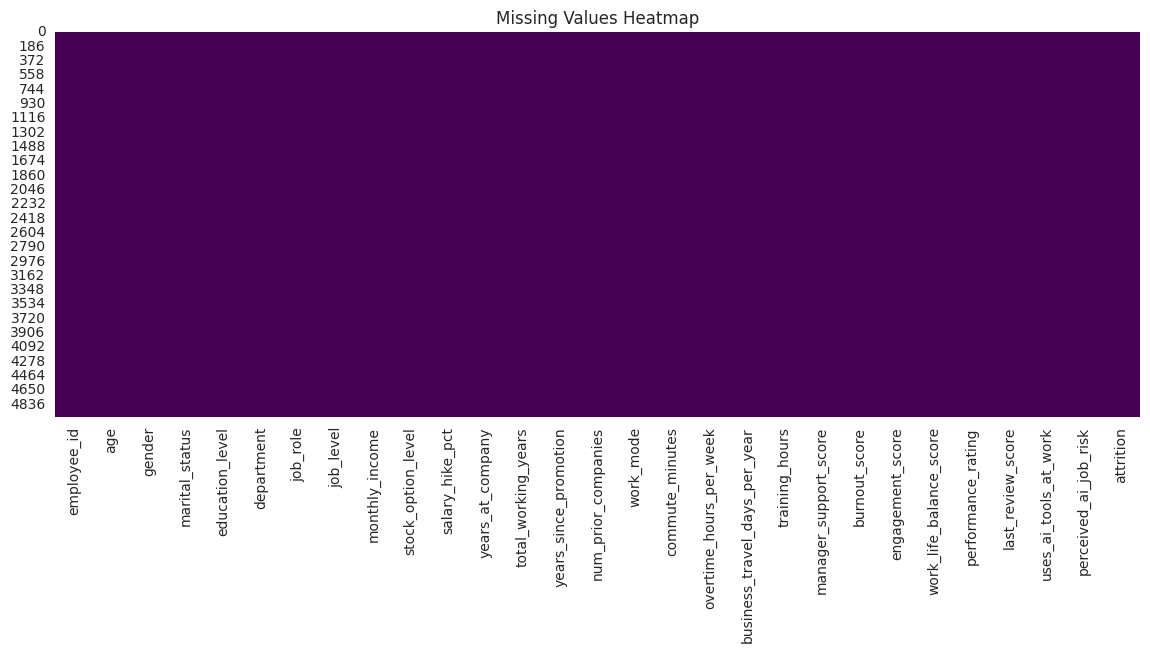

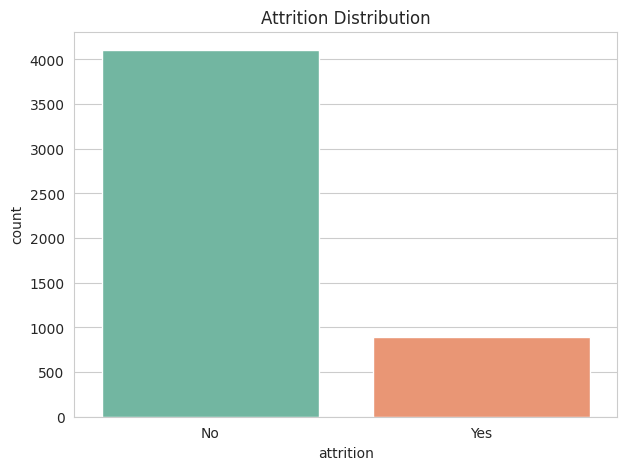

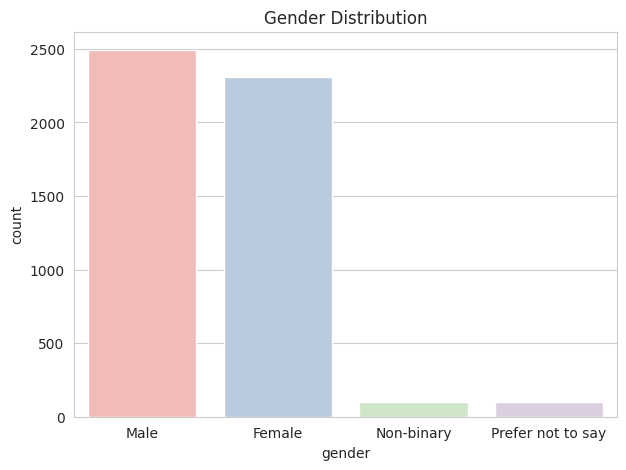

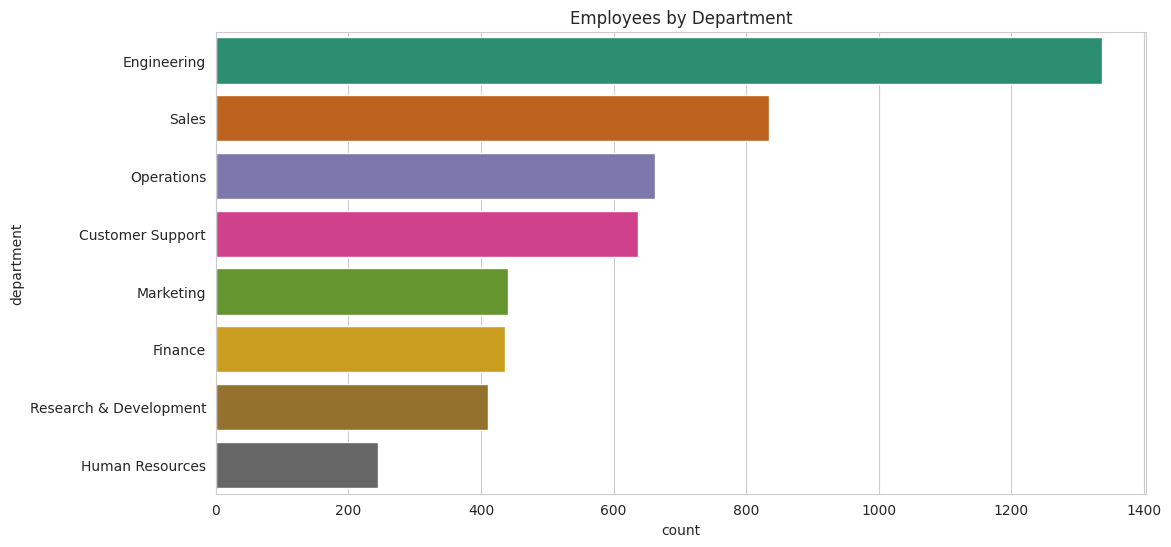

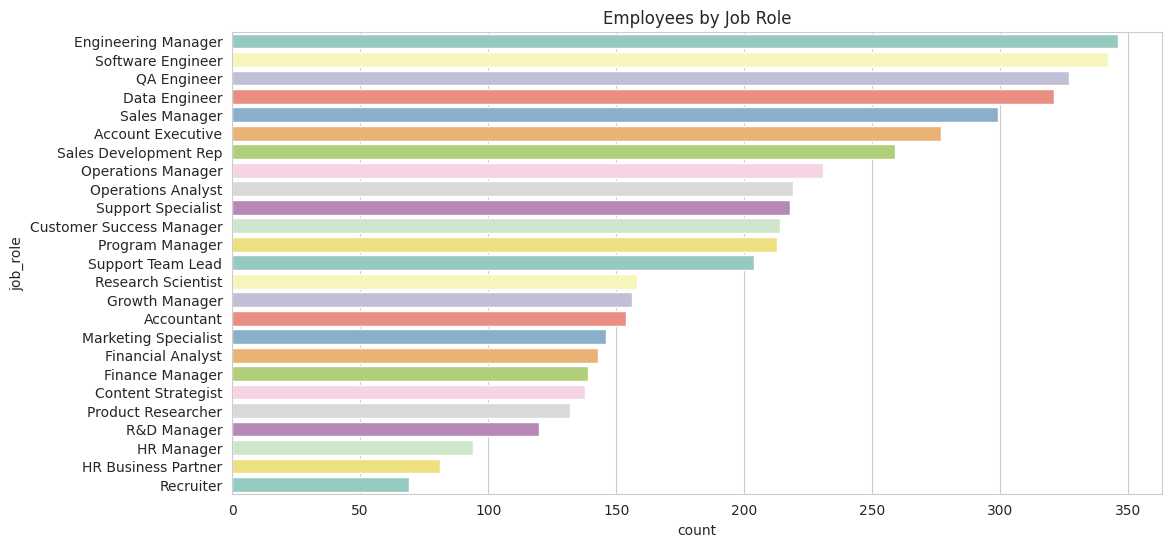

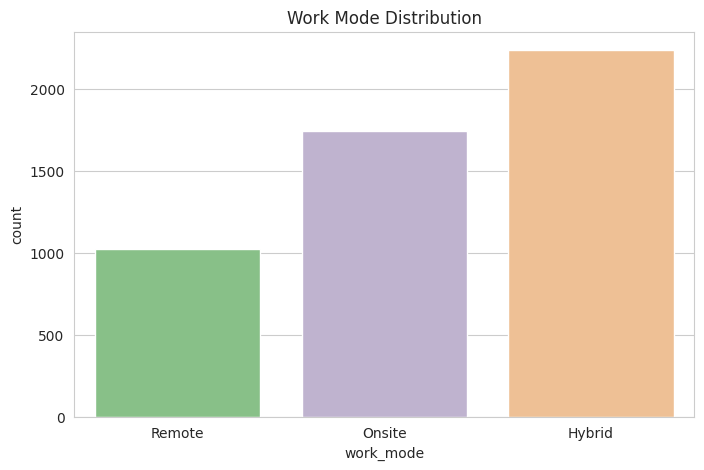

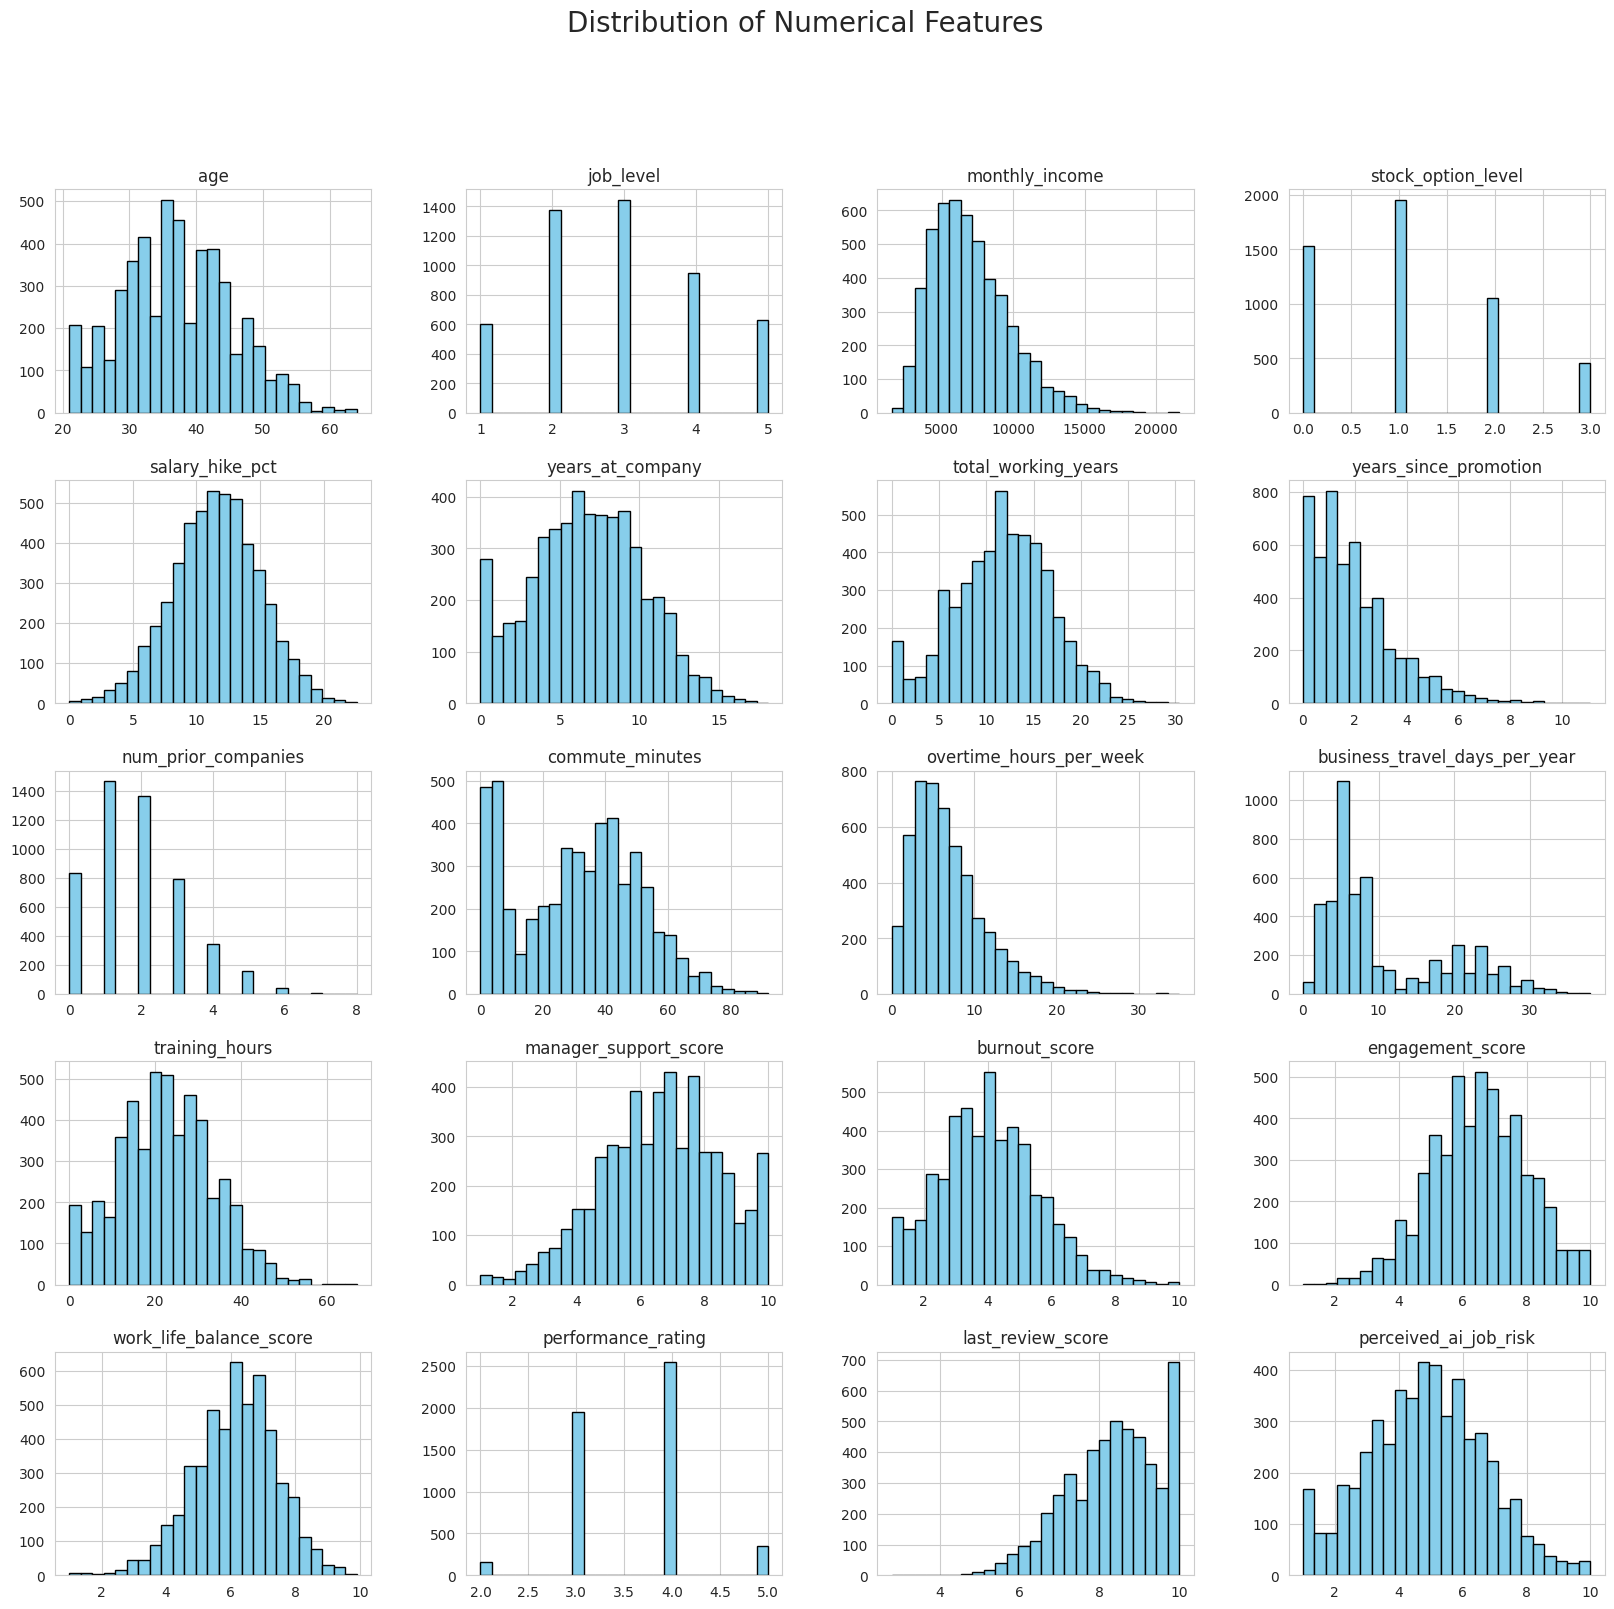

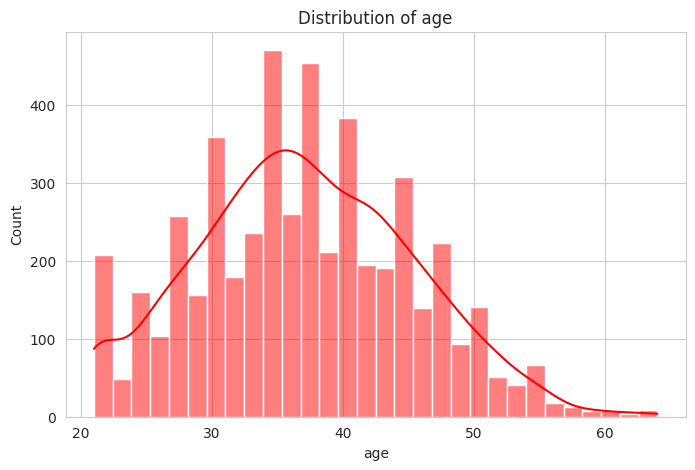

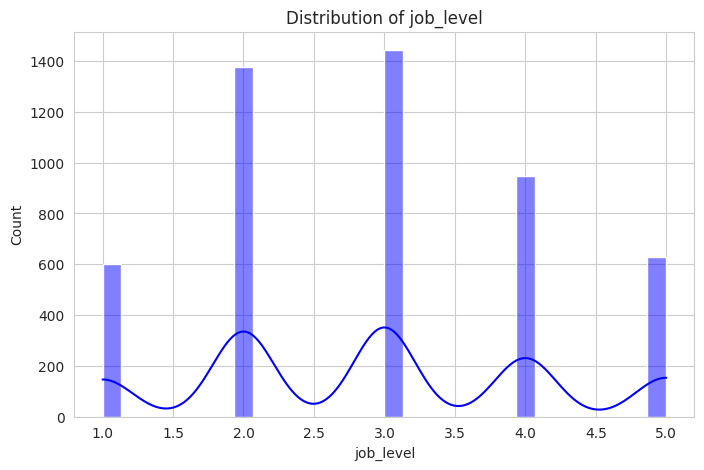

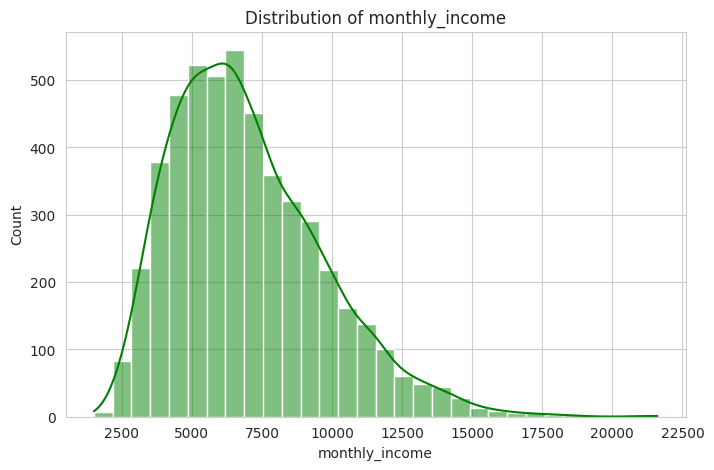

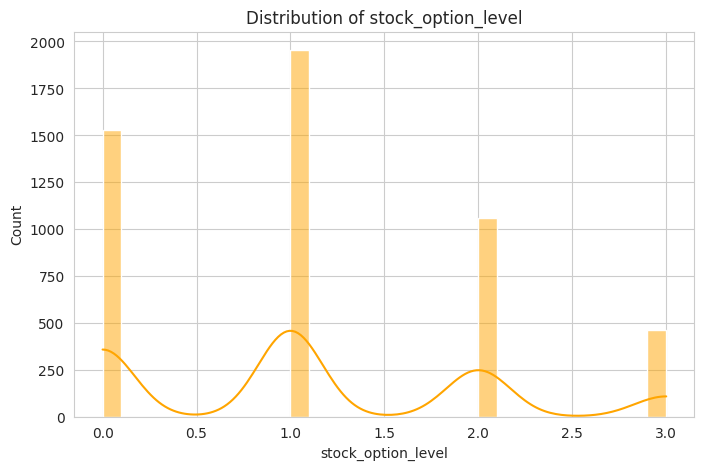

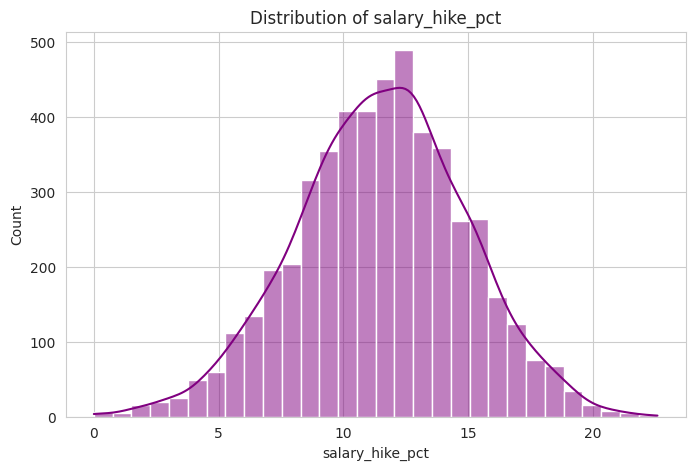

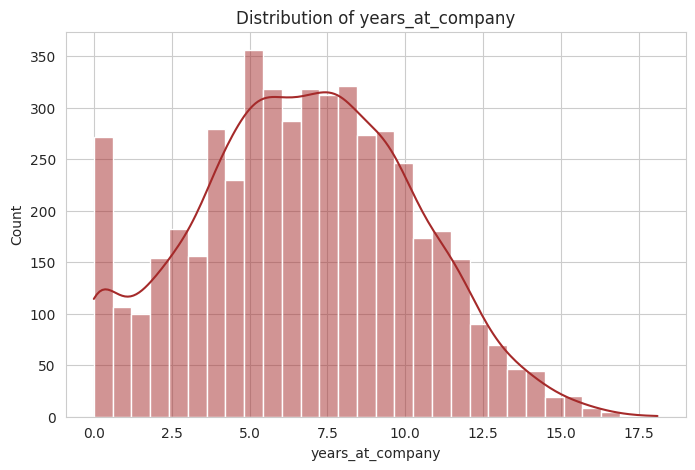

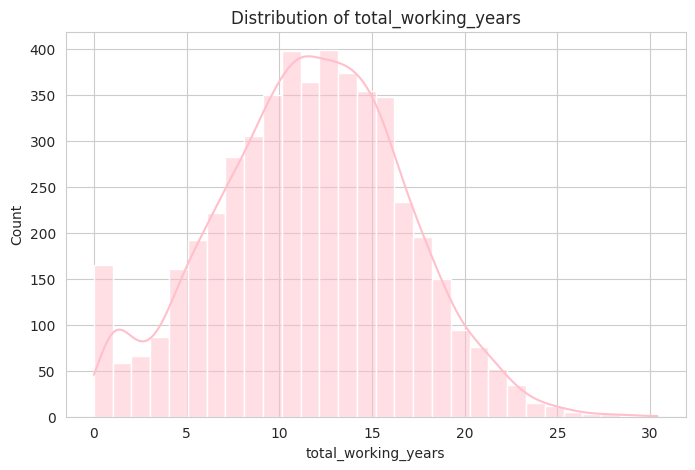

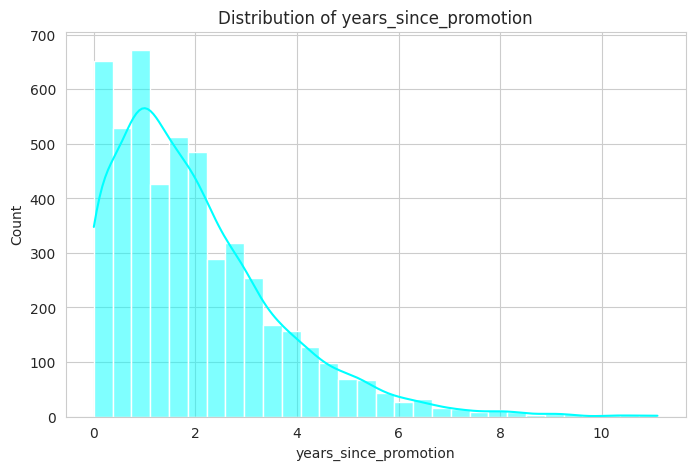

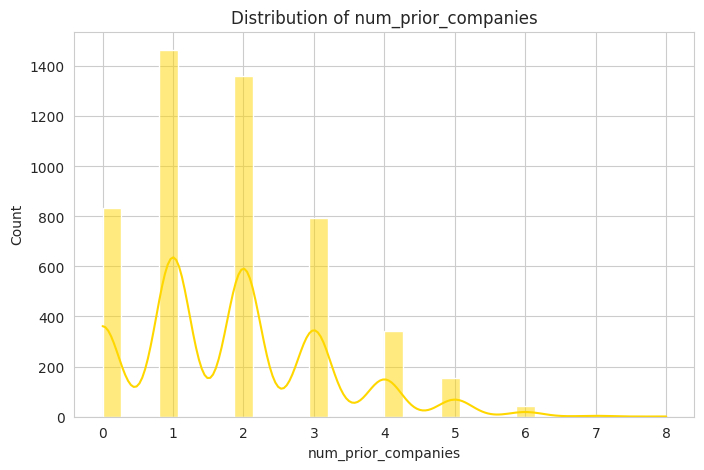

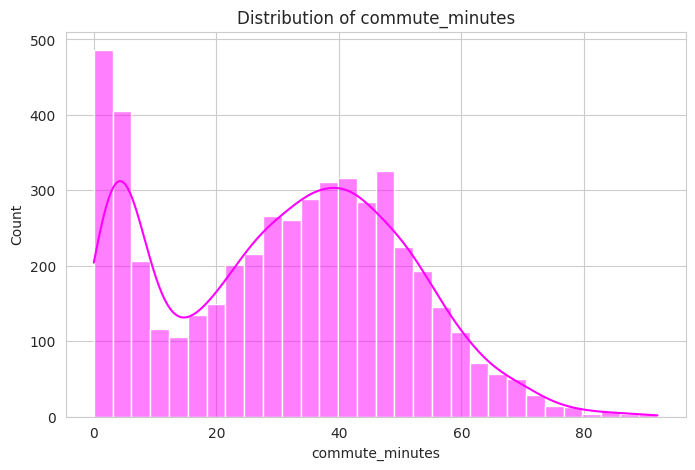

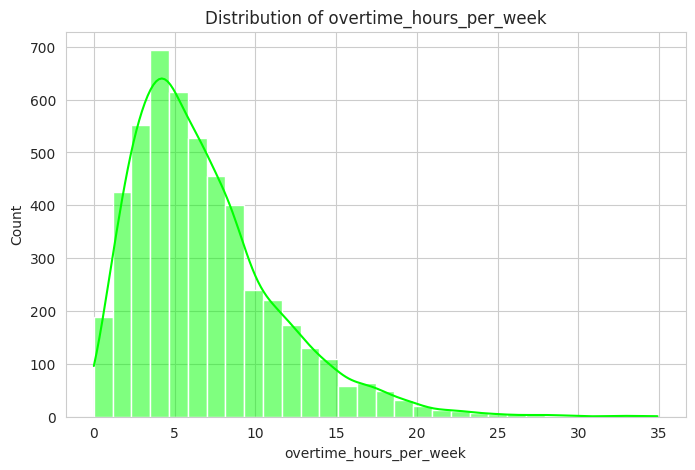

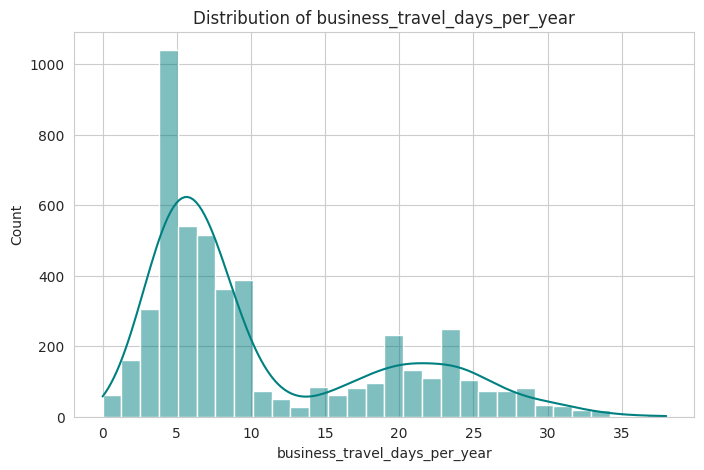

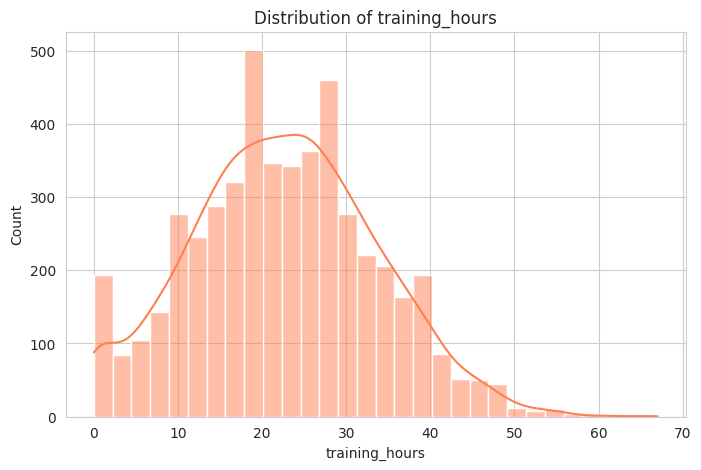

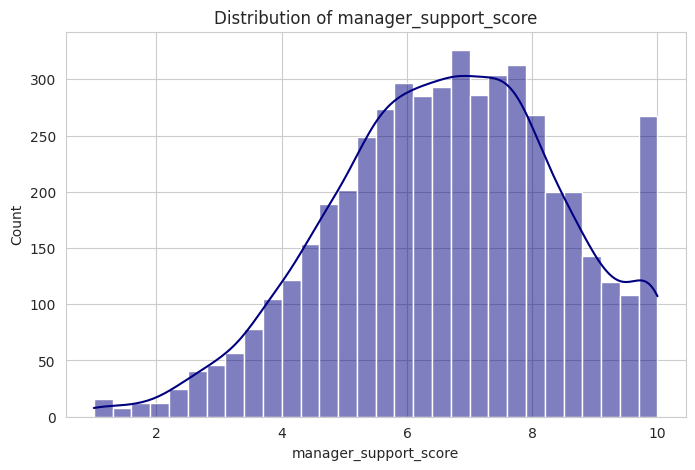

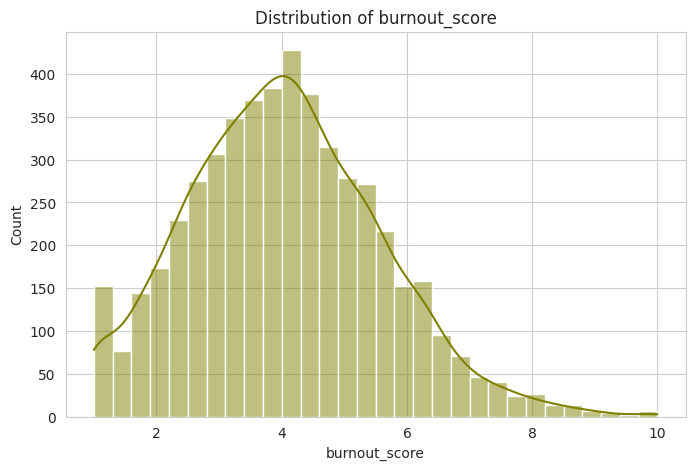

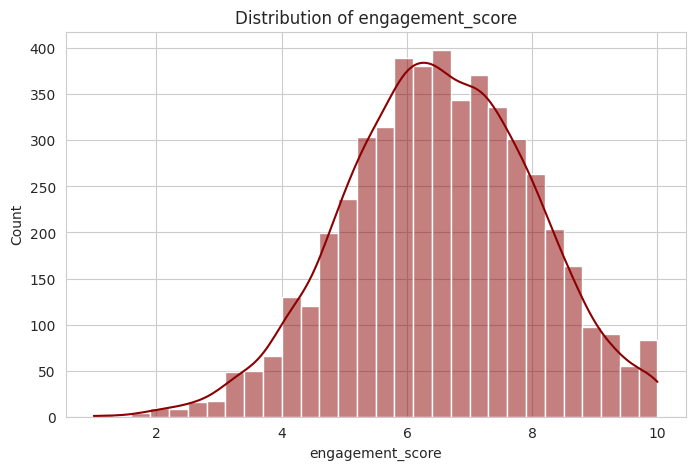

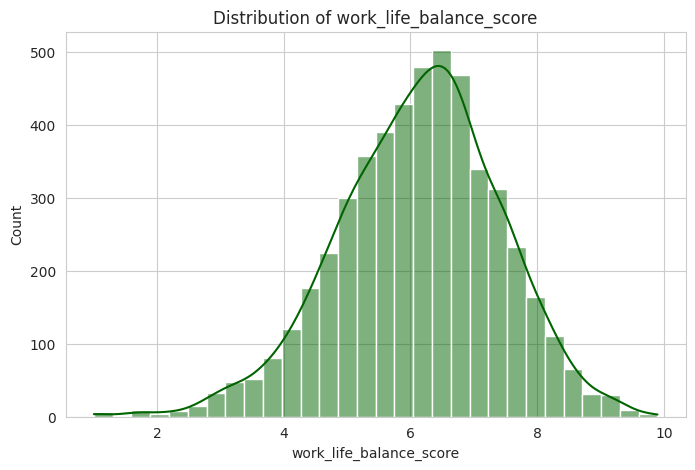

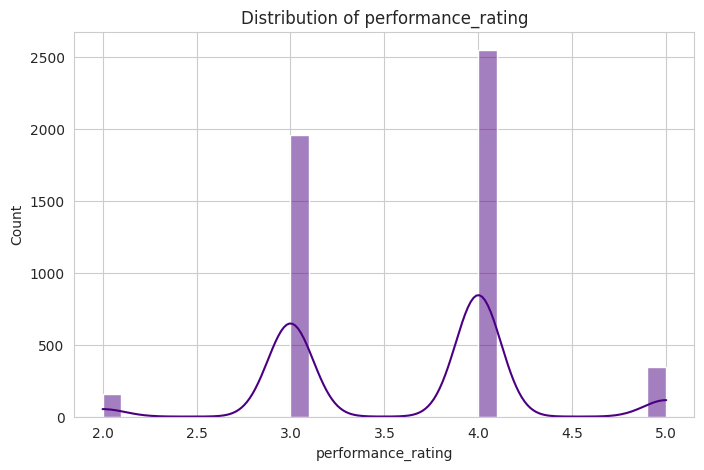

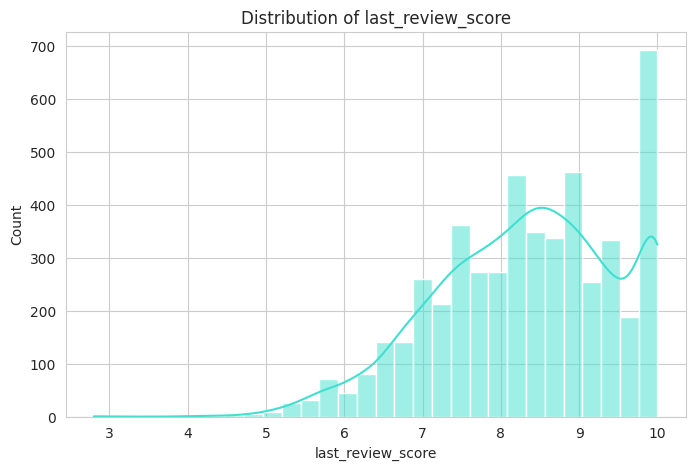

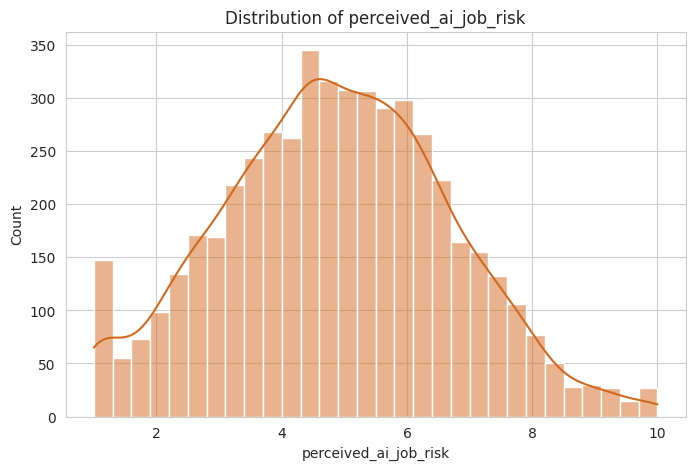

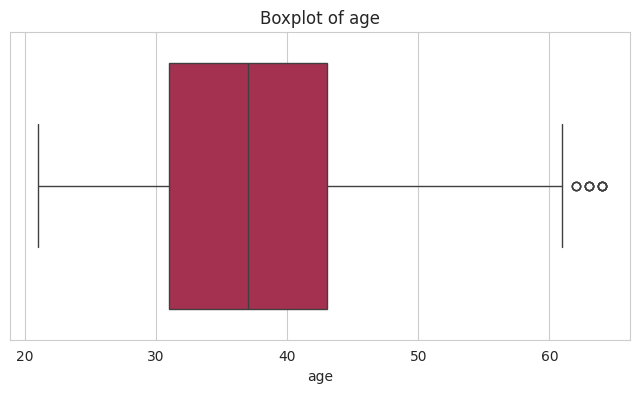

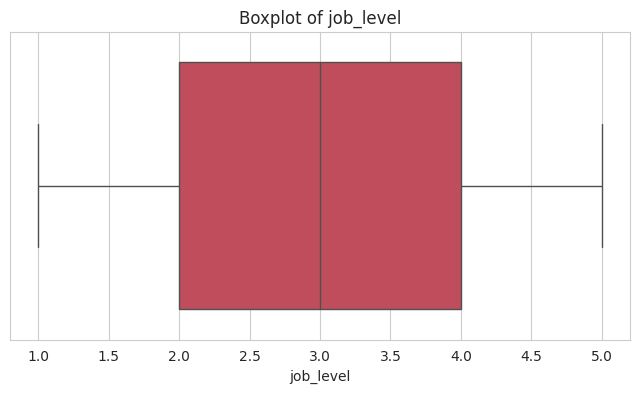

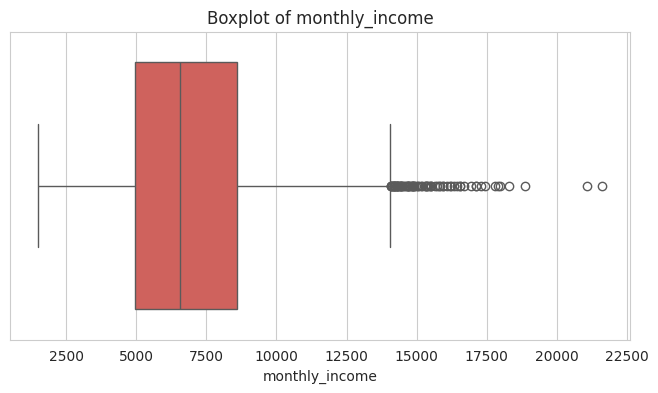

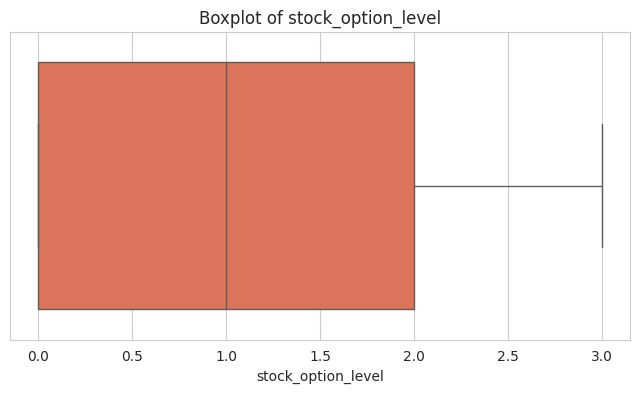

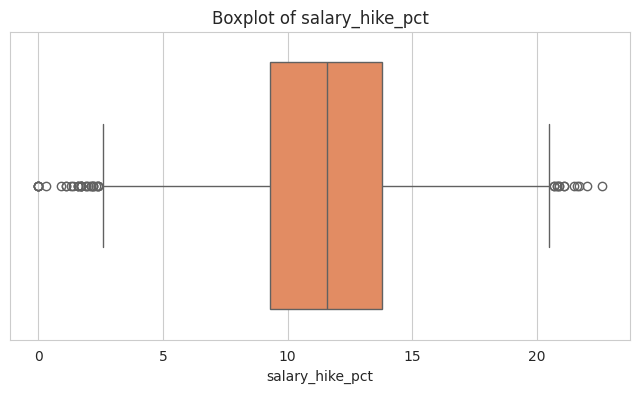

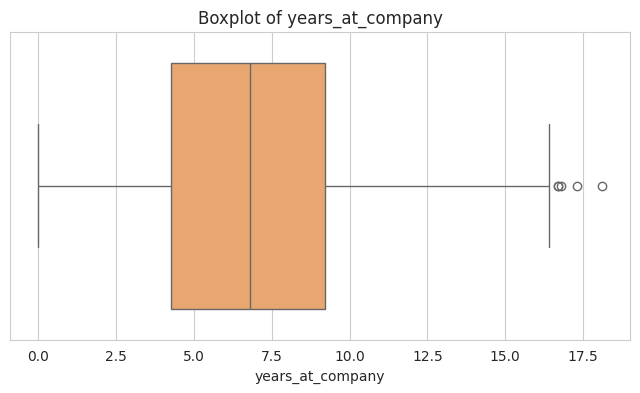

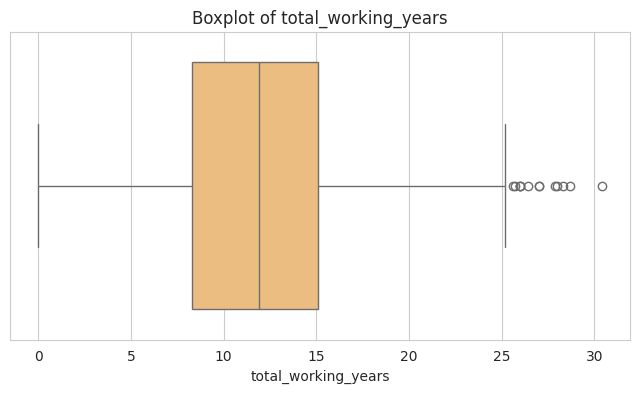

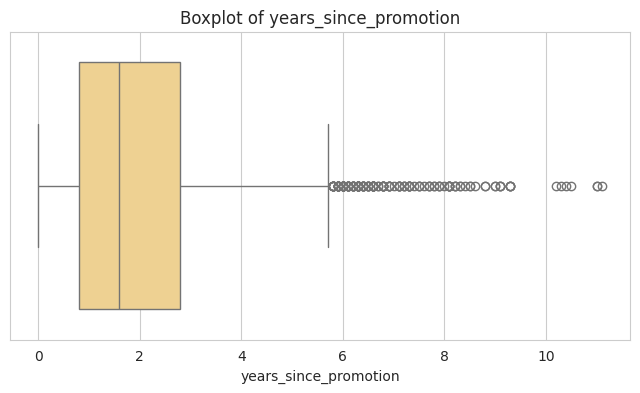

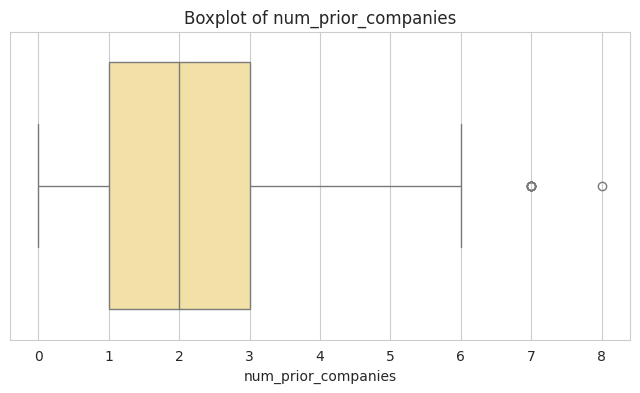

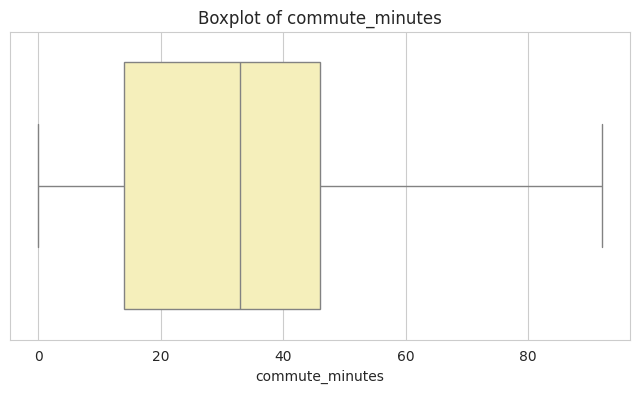

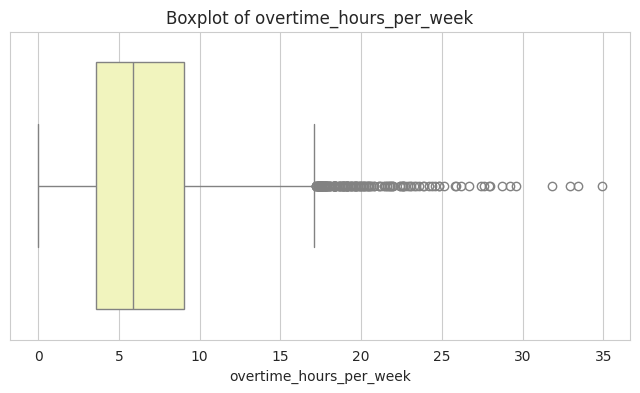

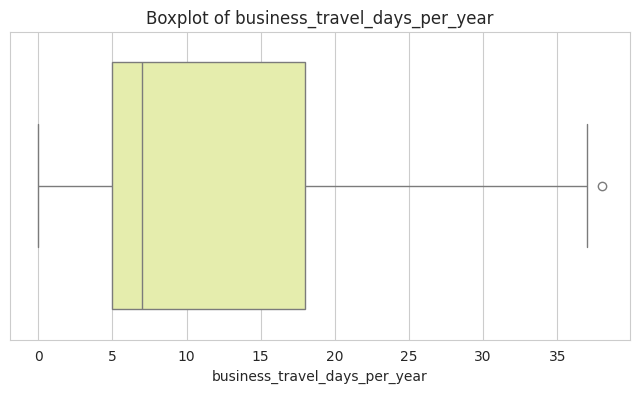

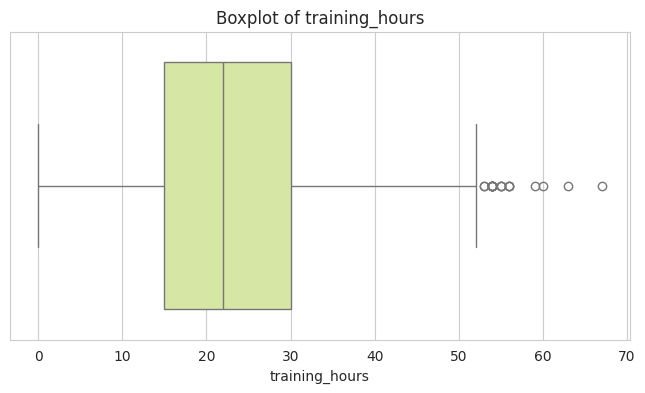

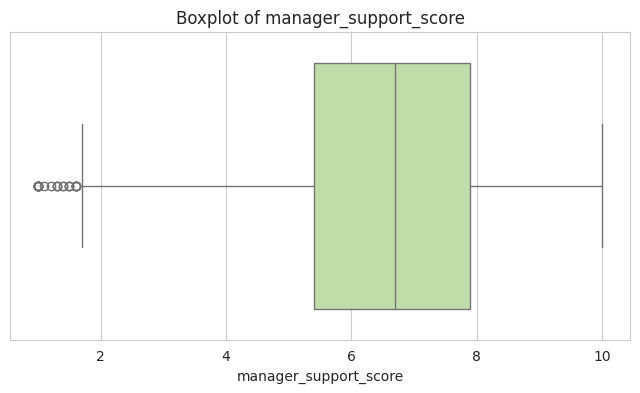

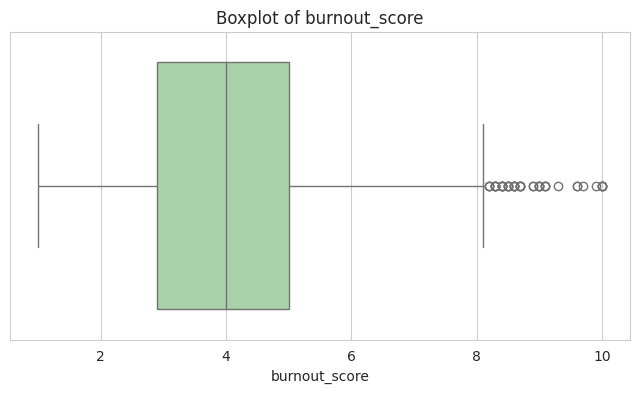

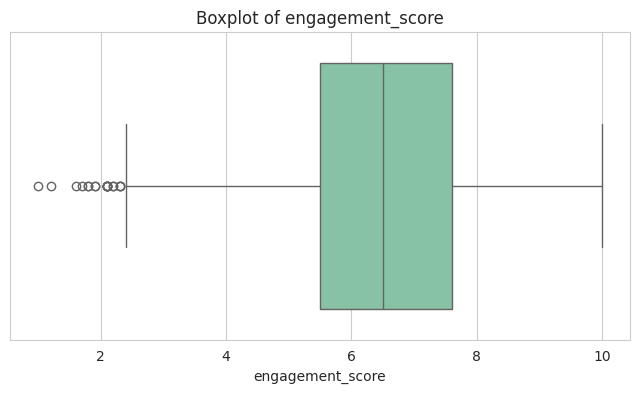

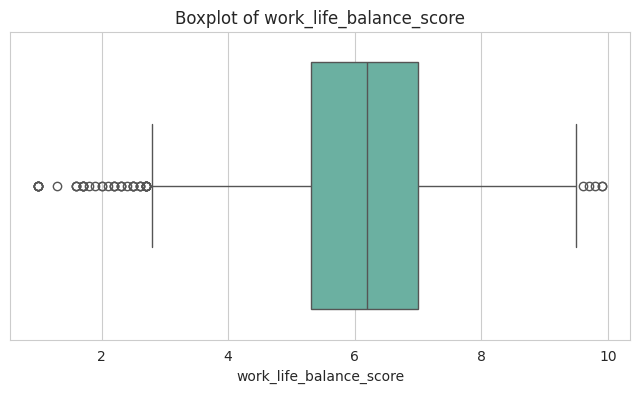

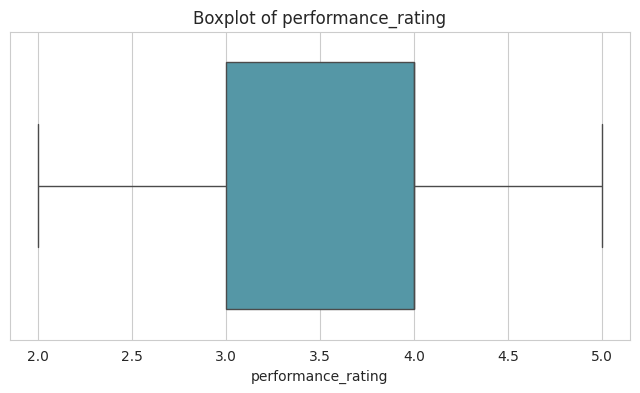

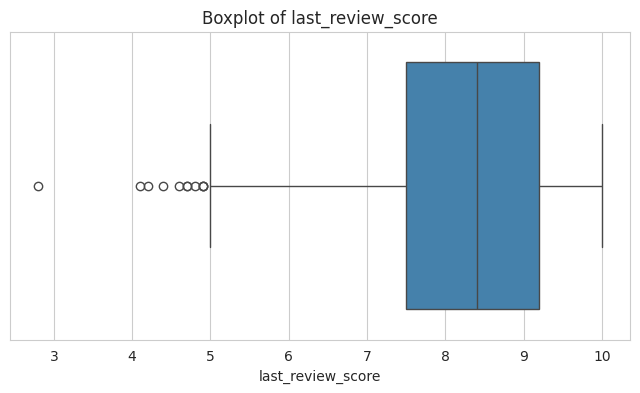

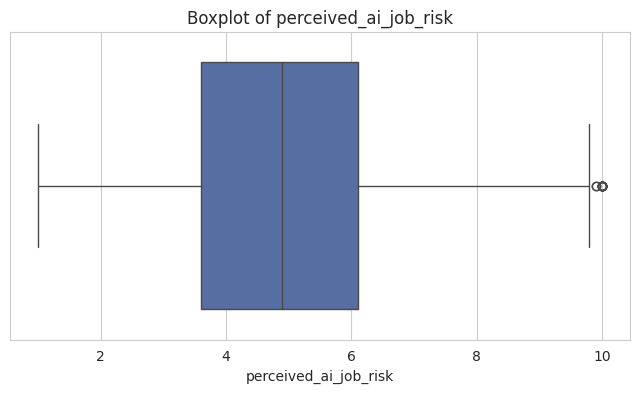

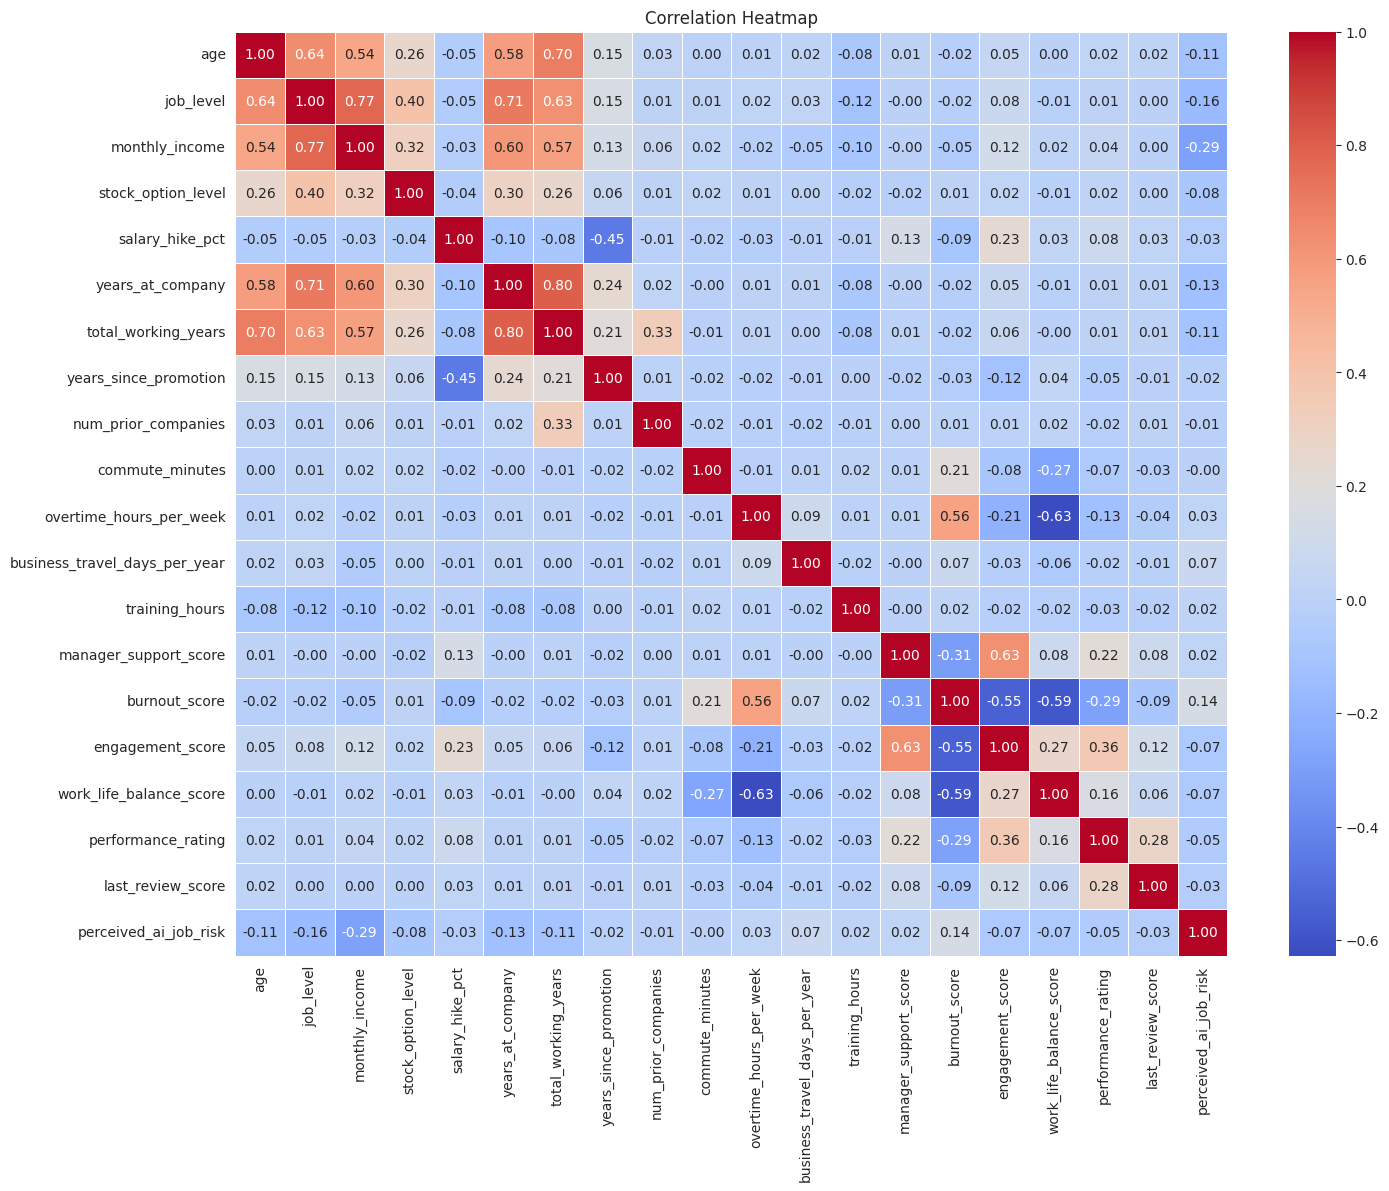

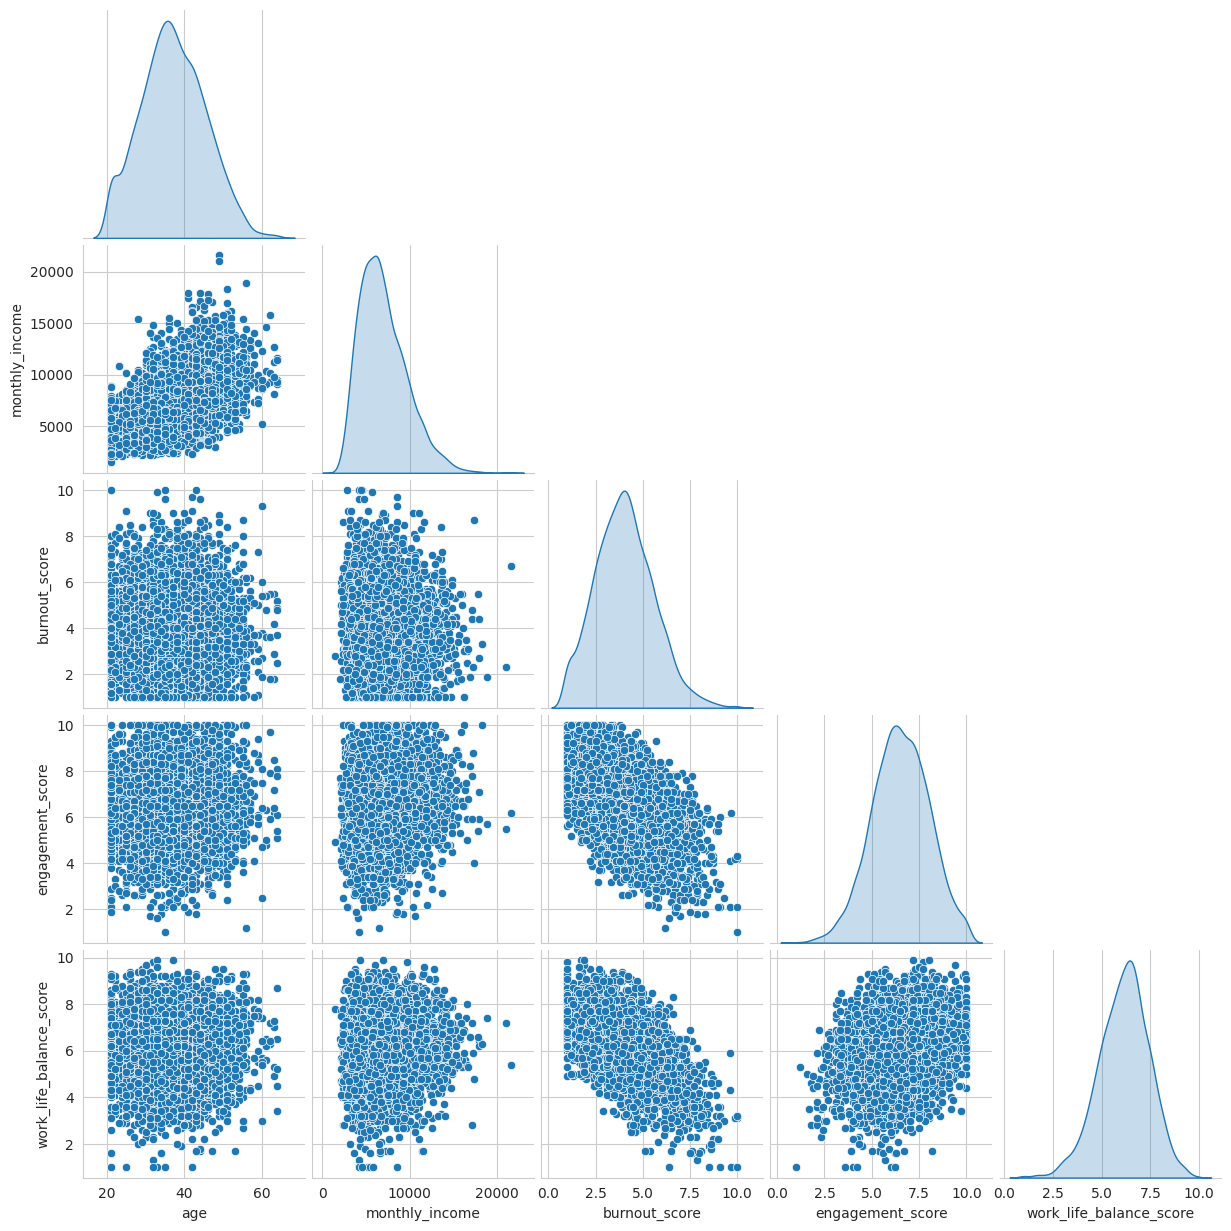

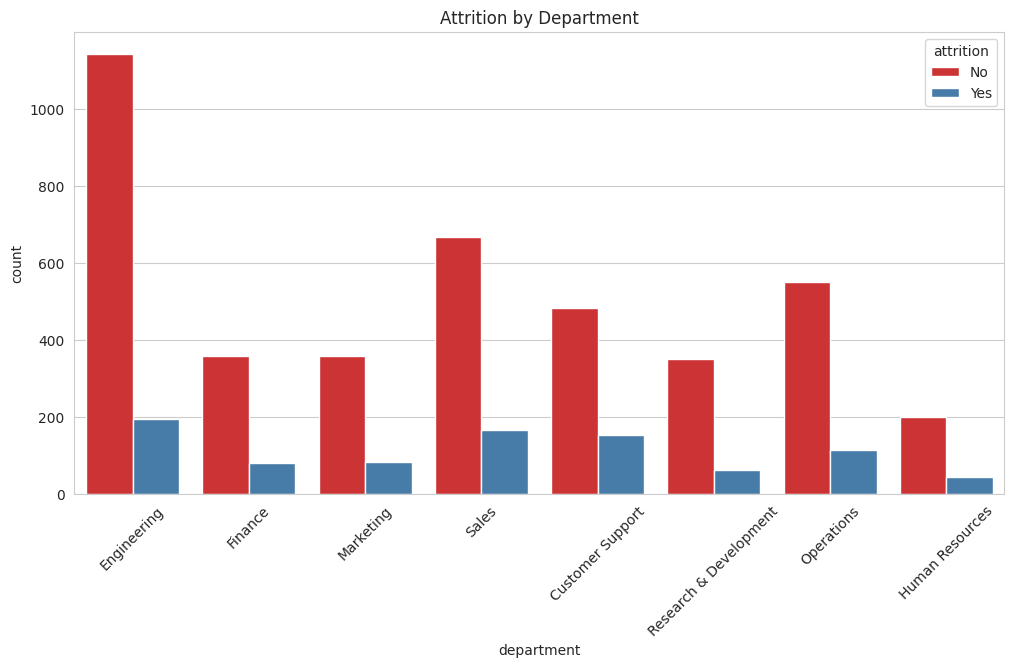

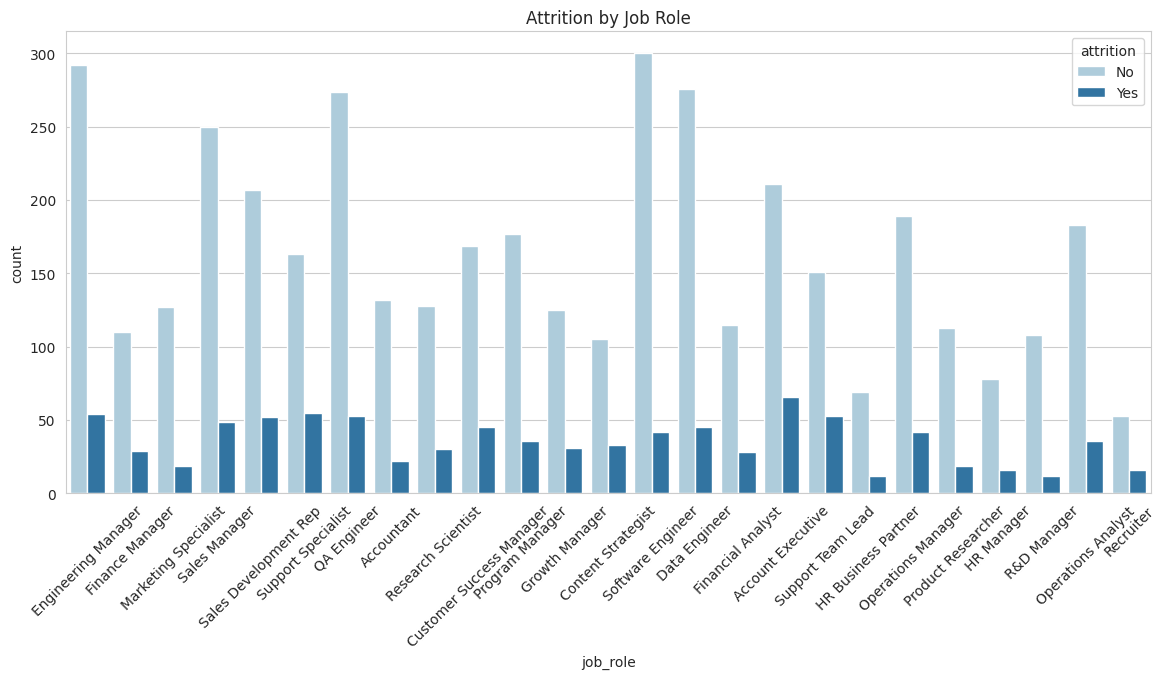

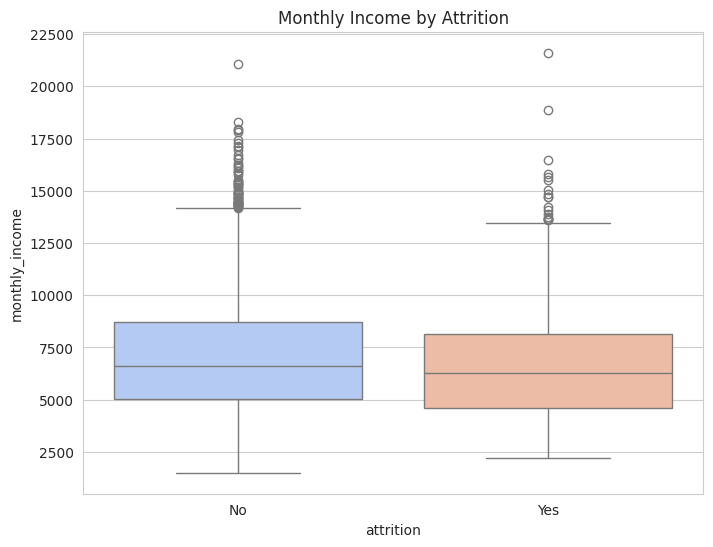

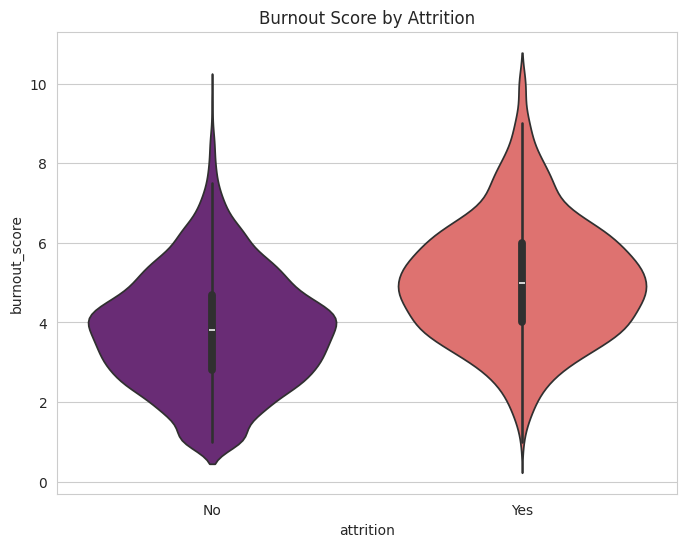

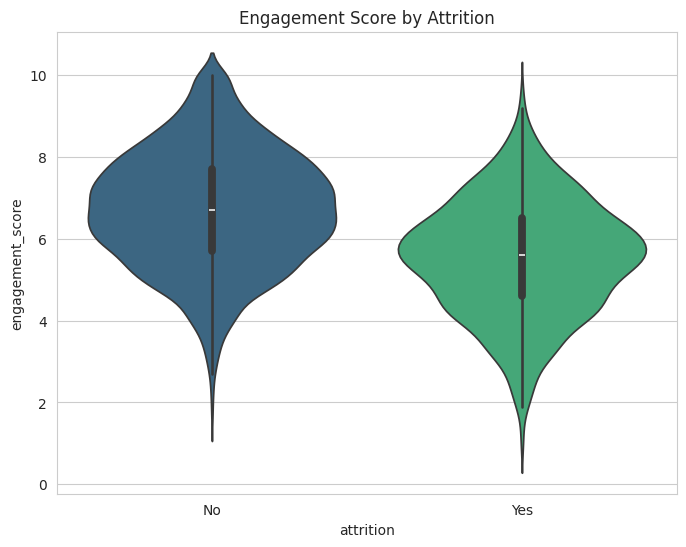

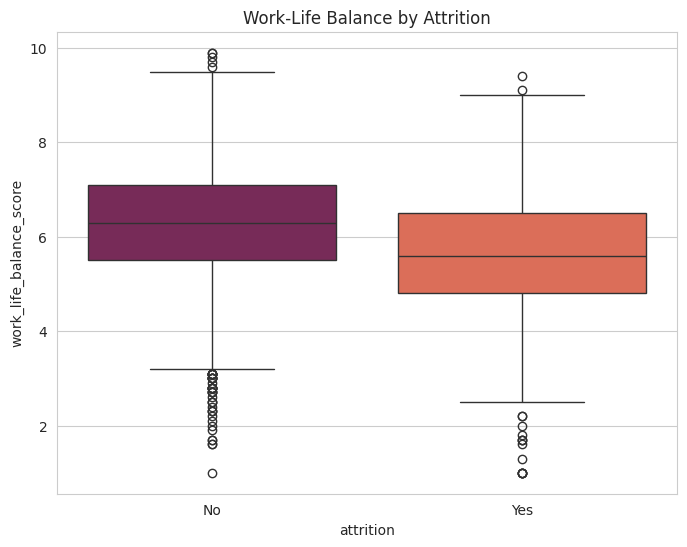

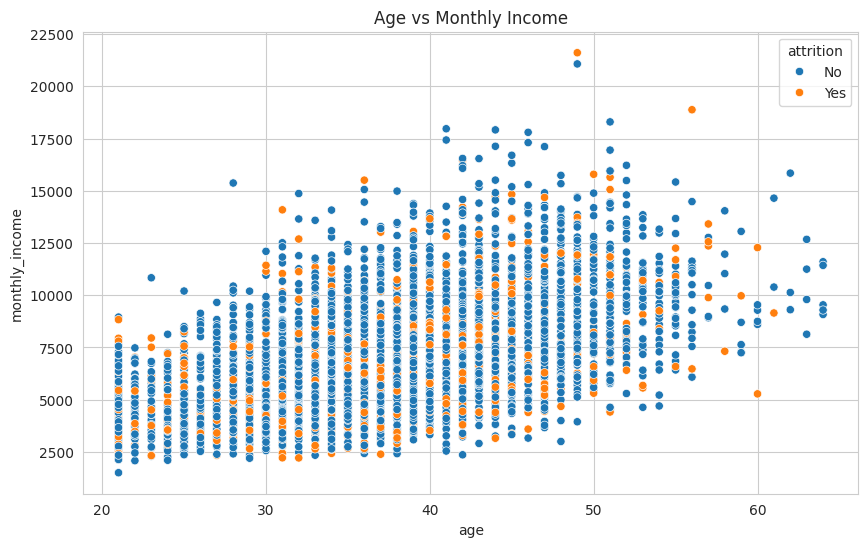

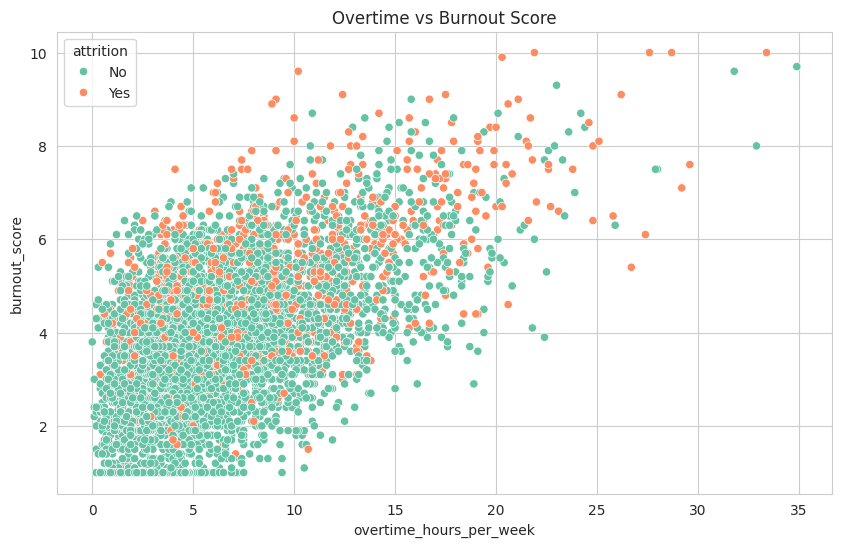

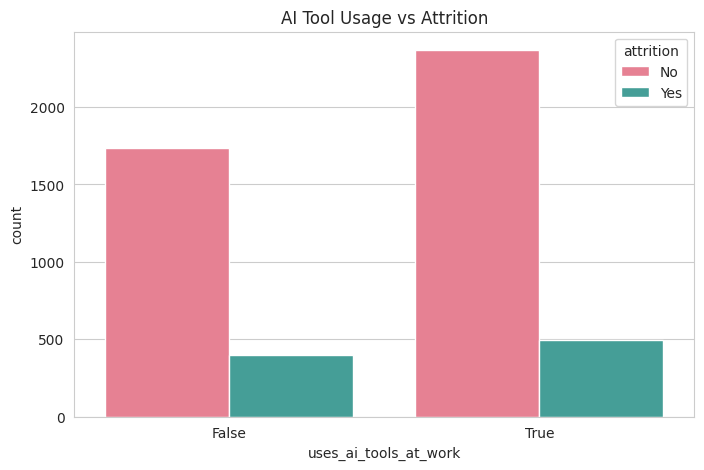

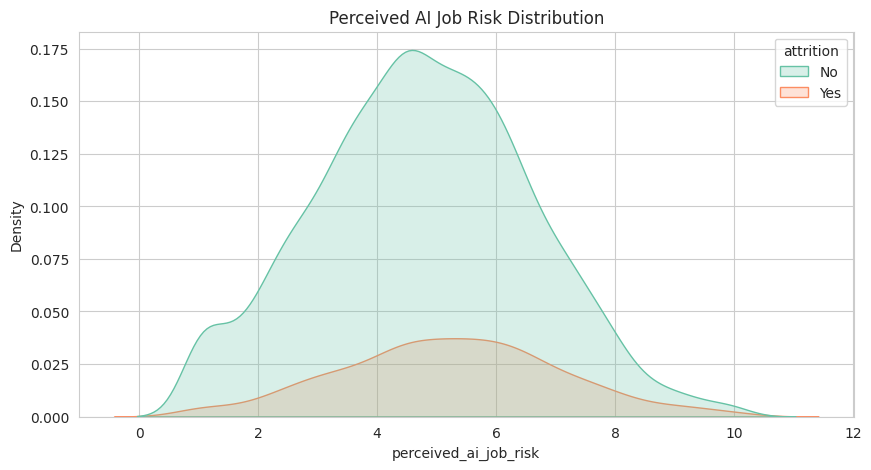

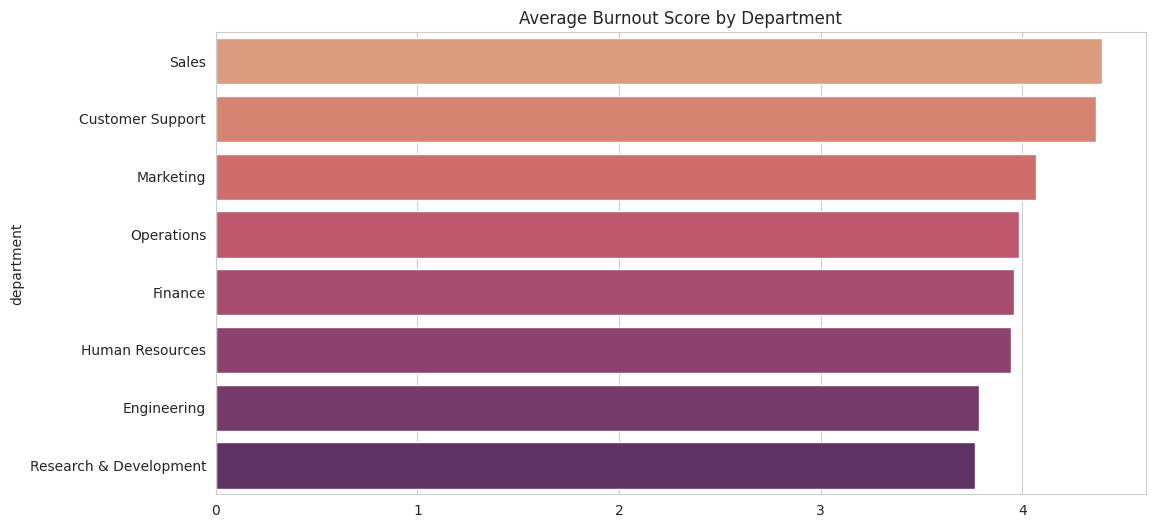

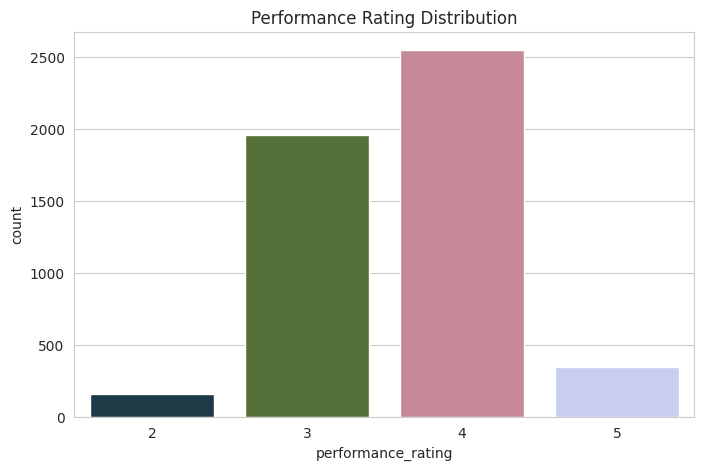

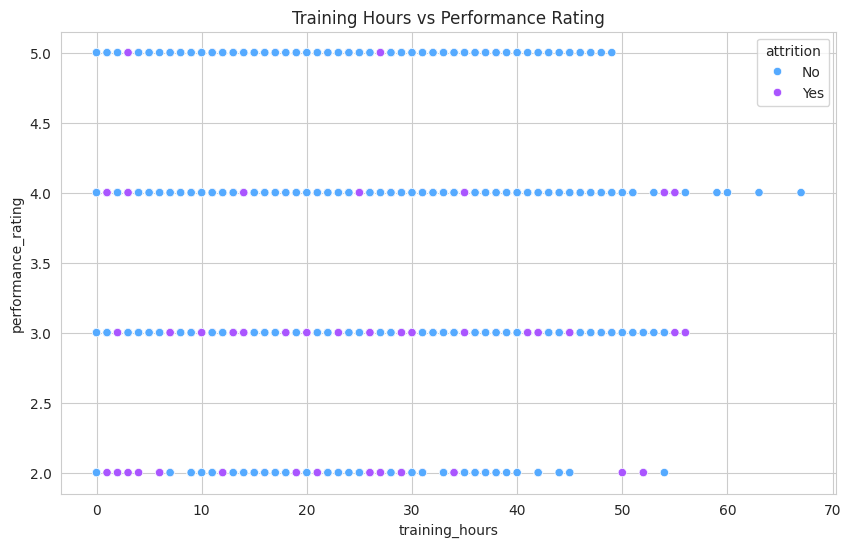

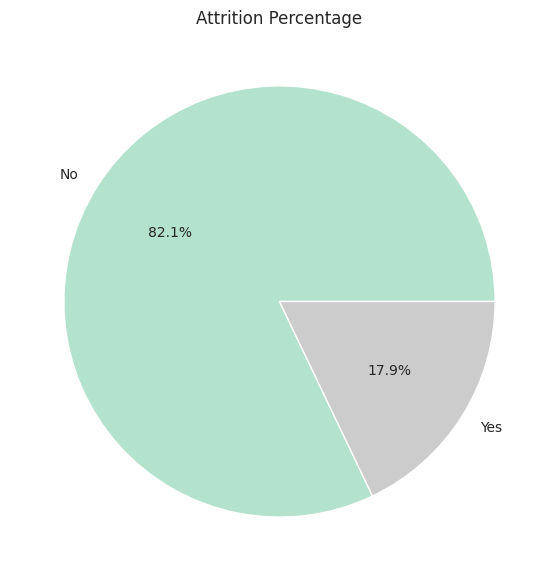

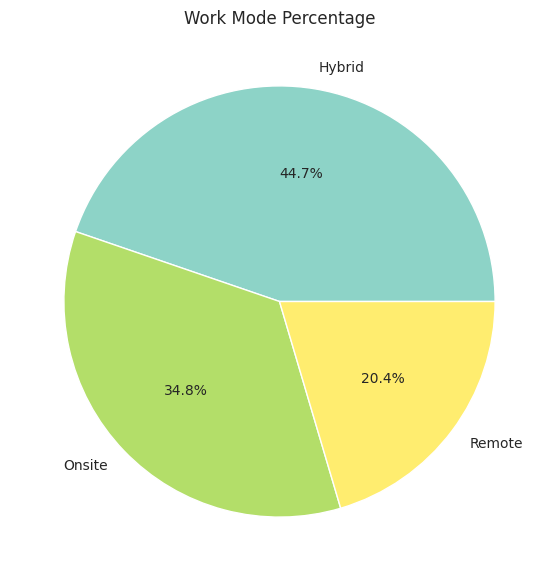

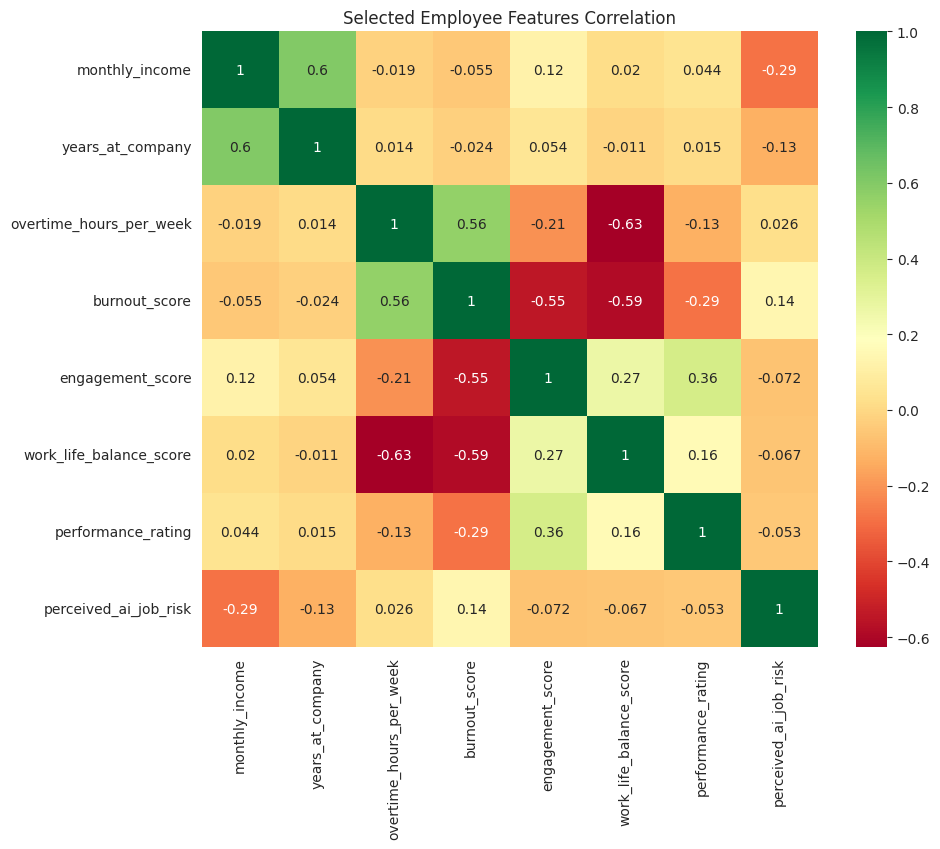

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# STYLE
# =========================================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================================================
# COPY DATA
# =========================================================

data = df.copy()

# =========================================================
# NUMERIC & CATEGORICAL COLUMNS
# =========================================================

num_cols = [
    "age",
    "job_level",
    "monthly_income",
    "stock_option_level",
    "salary_hike_pct",
    "years_at_company",
    "total_working_years",
    "years_since_promotion",
    "num_prior_companies",
    "commute_minutes",
    "overtime_hours_per_week",
    "business_travel_days_per_year",
    "training_hours",
    "manager_support_score",
    "burnout_score",
    "engagement_score",
    "work_life_balance_score",
    "performance_rating",
    "last_review_score",
    "perceived_ai_job_risk"
]

cat_cols = [
    "gender",
    "marital_status",
    "education_level",
    "department",
    "job_role",
    "work_mode",
    "uses_ai_tools_at_work",
    "attrition"
]

# =========================================================
# BASIC INFO
# =========================================================

print(data.info())
print(data.describe())

# =========================================================
# MISSING VALUE HEATMAP
# =========================================================

plt.figure(figsize=(14, 5))
sns.heatmap(data.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# =========================================================
# ATTRITION DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="attrition", palette="Set2")
plt.title("Attrition Distribution")
plt.show()

# =========================================================
# GENDER DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="gender", palette="Pastel1")
plt.title("Gender Distribution")
plt.show()

# =========================================================
# DEPARTMENT DISTRIBUTION
# =========================================================

plt.figure(figsize=(12, 6))
sns.countplot(data=data, y="department",
              order=data["department"].value_counts().index,
              palette="Dark2")
plt.title("Employees by Department")
plt.show()

# =========================================================
# JOB ROLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(12, 6))
sns.countplot(data=data, y="job_role",
              order=data["job_role"].value_counts().index,
              palette="Set3")
plt.title("Employees by Job Role")
plt.show()

# =========================================================
# WORK MODE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="work_mode", palette="Accent")
plt.title("Work Mode Distribution")
plt.show()

# =========================================================
# HISTOGRAMS FOR NUMERIC FEATURES
# =========================================================

data[num_cols].hist(
    bins=25,
    figsize=(20, 18),
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=20)
plt.show()

# =========================================================
# INDIVIDUAL COLORFUL DISTRIBUTIONS
# =========================================================

colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "cyan", "gold", "magenta",
    "lime", "teal", "coral", "navy", "olive",
    "darkred", "darkgreen", "indigo", "turquoise", "chocolate"
]

for col, color in zip(num_cols, colors):

    plt.figure(figsize=(8, 5))

    sns.histplot(data[col], kde=True, bins=30, color=color)

    plt.title(f"Distribution of {col}")
    plt.show()

# =========================================================
# BOXPLOTS
# =========================================================

palette = sns.color_palette("Spectral", len(num_cols))

for col, color in zip(num_cols, palette):

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=data[col], color=color)

    plt.title(f"Boxplot of {col}")
    plt.show()

# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(16, 12))

sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# =========================================================
# PAIRPLOT OF IMPORTANT FEATURES
# =========================================================

sns.pairplot(
    data[[
        "age",
        "monthly_income",
        "burnout_score",
        "engagement_score",
        "work_life_balance_score"
    ]],
    diag_kind="kde",
    corner=True
)

plt.show()

# =========================================================
# ATTRITION VS DEPARTMENT
# =========================================================

plt.figure(figsize=(12, 6))
sns.countplot(data=data, x="department", hue="attrition", palette="Set1")
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# ATTRITION VS JOB ROLE
# =========================================================

plt.figure(figsize=(14, 6))
sns.countplot(data=data, x="job_role", hue="attrition", palette="Paired")
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# SALARY BY ATTRITION
# =========================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="attrition", y="monthly_income", palette="coolwarm")
plt.title("Monthly Income by Attrition")
plt.show()

# =========================================================
# BURNOUT VS ATTRITION
# =========================================================

plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x="attrition", y="burnout_score", palette="magma")
plt.title("Burnout Score by Attrition")
plt.show()

# =========================================================
# ENGAGEMENT VS ATTRITION
# =========================================================

plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x="attrition", y="engagement_score", palette="viridis")
plt.title("Engagement Score by Attrition")
plt.show()

# =========================================================
# WORK-LIFE BALANCE VS ATTRITION
# =========================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="attrition", y="work_life_balance_score", palette="rocket")
plt.title("Work-Life Balance by Attrition")
plt.show()

# =========================================================
# SCATTER PLOTS
# =========================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x="age",
                y="monthly_income",
                hue="attrition",
                palette="tab10")
plt.title("Age vs Monthly Income")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x="overtime_hours_per_week",
                y="burnout_score",
                hue="attrition",
                palette="Set2")
plt.title("Overtime vs Burnout Score")
plt.show()

# =========================================================
# AI TOOLS USAGE ANALYSIS
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=data,
              x="uses_ai_tools_at_work",
              hue="attrition",
              palette="husl")
plt.title("AI Tool Usage vs Attrition")
plt.show()

# =========================================================
# PERCEIVED AI RISK DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))
sns.kdeplot(data=data,
            x="perceived_ai_job_risk",
            hue="attrition",
            fill=True,
            palette="Set2")
plt.title("Perceived AI Job Risk Distribution")
plt.show()

# =========================================================
# TOP DEPARTMENTS BY AVERAGE BURNOUT
# =========================================================

burnout_avg = (
    data.groupby("department")["burnout_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=burnout_avg.values,
            y=burnout_avg.index,
            palette="flare")
plt.title("Average Burnout Score by Department")
plt.show()

# =========================================================
# PERFORMANCE RATING DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=data,
              x="performance_rating",
              palette="cubehelix")
plt.title("Performance Rating Distribution")
plt.show()

# =========================================================
# TRAINING HOURS VS PERFORMANCE
# =========================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x="training_hours",
                y="performance_rating",
                hue="attrition",
                palette="cool")
plt.title("Training Hours vs Performance Rating")
plt.show()

# =========================================================
# PIE CHARTS
# =========================================================

plt.figure(figsize=(7, 7))
data["attrition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel2"
)
plt.ylabel("")
plt.title("Attrition Percentage")
plt.show()

plt.figure(figsize=(7, 7))
data["work_mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)
plt.ylabel("")
plt.title("Work Mode Percentage")
plt.show()

# =========================================================
# FINAL SUMMARY HEATMAP
# =========================================================

selected = [
    "monthly_income",
    "years_at_company",
    "overtime_hours_per_week",
    "burnout_score",
    "engagement_score",
    "work_life_balance_score",
    "performance_rating",
    "perceived_ai_job_risk"
]

plt.figure(figsize=(10, 8))
sns.heatmap(data[selected].corr(),
            annot=True,
            cmap="RdYlGn",
            square=True)
plt.title("Selected Employee Features Correlation")
plt.show()

## Features Engineering


Logistic Regression
Accuracy : 0.839
Precision: 0.68
Recall   : 0.1899
F1 Score : 0.2969
ROC AUC  : 0.8028

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       821
           1       0.68      0.19      0.30       179

    accuracy                           0.84      1000
   macro avg       0.76      0.59      0.60      1000
weighted avg       0.82      0.84      0.80      1000


Confusion Matrix:

[[805  16]
 [145  34]]


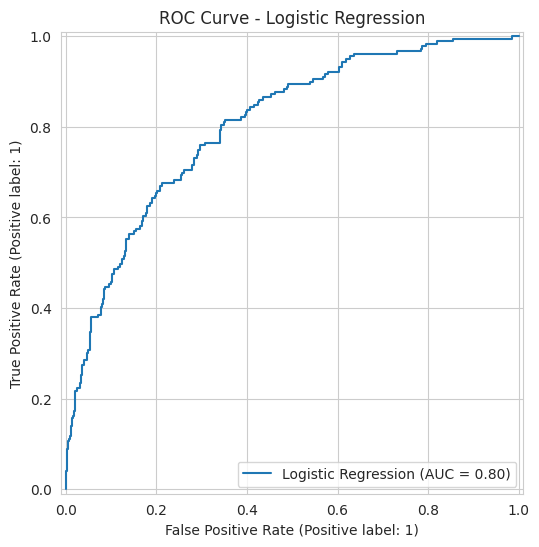


Decision Tree
Accuracy : 0.754
Precision: 0.3064
Recall   : 0.2961
F1 Score : 0.3011
ROC AUC  : 0.575

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       821
           1       0.31      0.30      0.30       179

    accuracy                           0.75      1000
   macro avg       0.58      0.57      0.58      1000
weighted avg       0.75      0.75      0.75      1000


Confusion Matrix:

[[701 120]
 [126  53]]


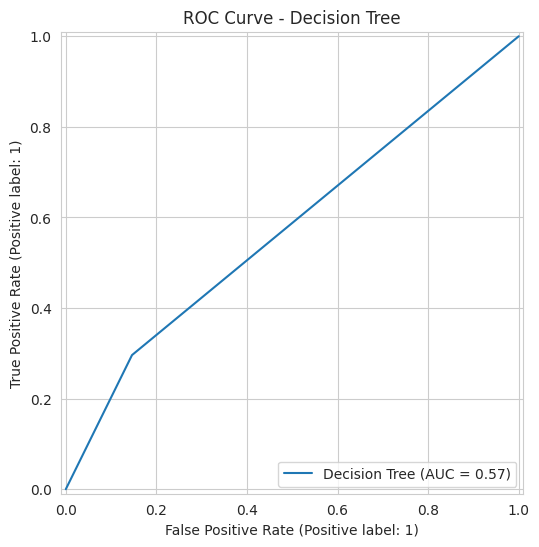


Random Forest
Accuracy : 0.838
Precision: 0.7429
Recall   : 0.1453
F1 Score : 0.243
ROC AUC  : 0.7915

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       821
           1       0.74      0.15      0.24       179

    accuracy                           0.84      1000
   macro avg       0.79      0.57      0.58      1000
weighted avg       0.82      0.84      0.79      1000


Confusion Matrix:

[[812   9]
 [153  26]]


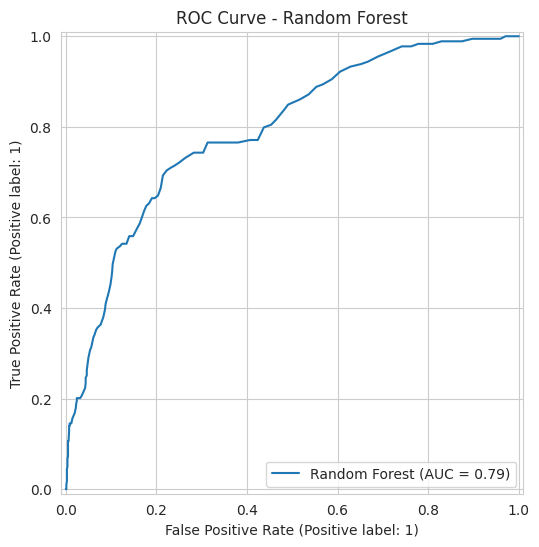


Gradient Boosting
Accuracy : 0.84
Precision: 0.6863
Recall   : 0.1955
F1 Score : 0.3043
ROC AUC  : 0.7848

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       821
           1       0.69      0.20      0.30       179

    accuracy                           0.84      1000
   macro avg       0.77      0.59      0.61      1000
weighted avg       0.82      0.84      0.80      1000


Confusion Matrix:

[[805  16]
 [144  35]]


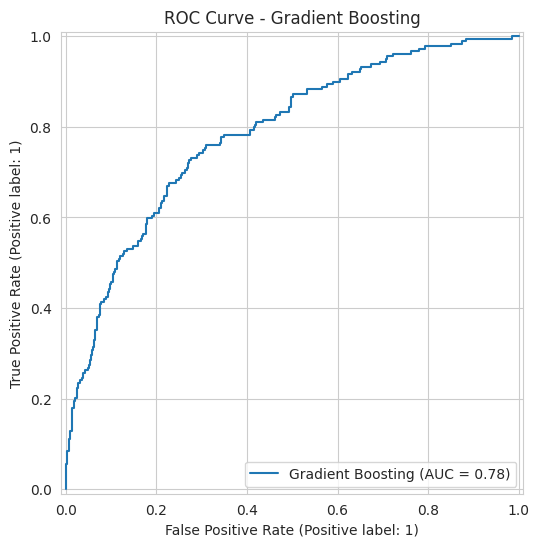


Extra Trees
Accuracy : 0.83
Precision: 0.6957
Recall   : 0.0894
F1 Score : 0.1584
ROC AUC  : 0.7826

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.99      0.91       821
           1       0.70      0.09      0.16       179

    accuracy                           0.83      1000
   macro avg       0.76      0.54      0.53      1000
weighted avg       0.81      0.83      0.77      1000


Confusion Matrix:

[[814   7]
 [163  16]]


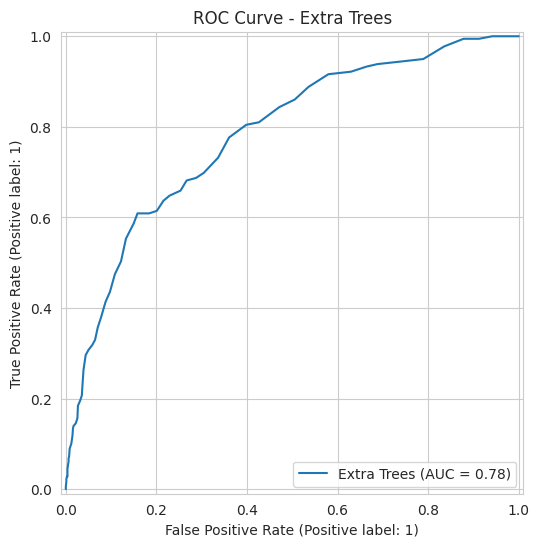


AdaBoost
Accuracy : 0.83
Precision: 0.6047
Recall   : 0.1453
F1 Score : 0.2342
ROC AUC  : 0.787

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       821
           1       0.60      0.15      0.23       179

    accuracy                           0.83      1000
   macro avg       0.72      0.56      0.57      1000
weighted avg       0.80      0.83      0.78      1000


Confusion Matrix:

[[804  17]
 [153  26]]


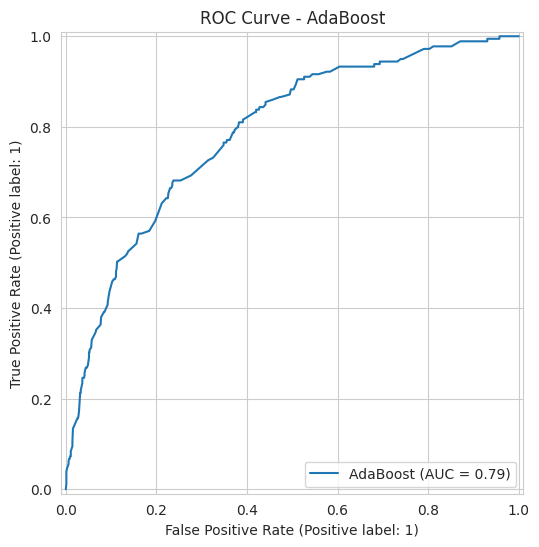


KNN
Accuracy : 0.806
Precision: 0.3881
Recall   : 0.1453
F1 Score : 0.2114
ROC AUC  : 0.6594

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89       821
           1       0.39      0.15      0.21       179

    accuracy                           0.81      1000
   macro avg       0.61      0.55      0.55      1000
weighted avg       0.76      0.81      0.77      1000


Confusion Matrix:

[[780  41]
 [153  26]]


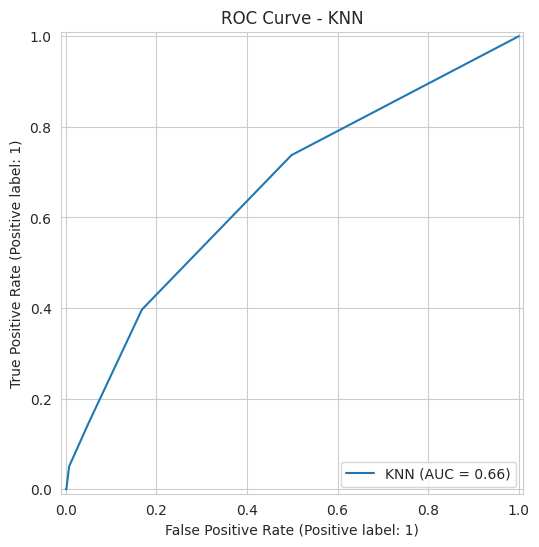


Gaussian NB
Accuracy : 0.795
Precision: 0.4393
Recall   : 0.5251
F1 Score : 0.4784
ROC AUC  : 0.7916

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       821
           1       0.44      0.53      0.48       179

    accuracy                           0.80      1000
   macro avg       0.67      0.69      0.68      1000
weighted avg       0.81      0.80      0.80      1000


Confusion Matrix:

[[701 120]
 [ 85  94]]


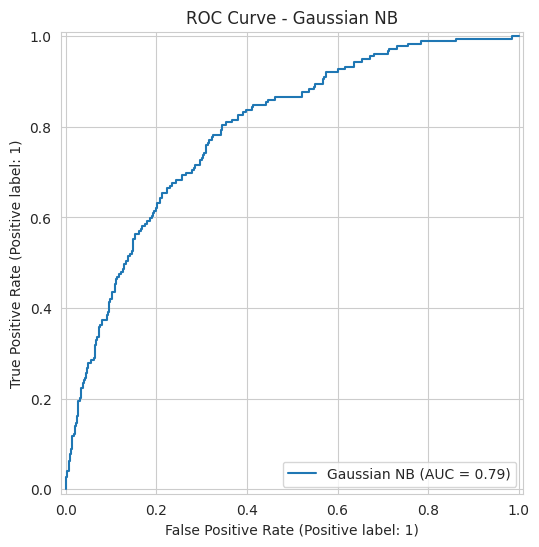


SVM
Accuracy : 0.83
Precision: 0.7143
Recall   : 0.0838
F1 Score : 0.15
ROC AUC  : 0.7187

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.99      0.91       821
           1       0.71      0.08      0.15       179

    accuracy                           0.83      1000
   macro avg       0.77      0.54      0.53      1000
weighted avg       0.81      0.83      0.77      1000


Confusion Matrix:

[[815   6]
 [164  15]]


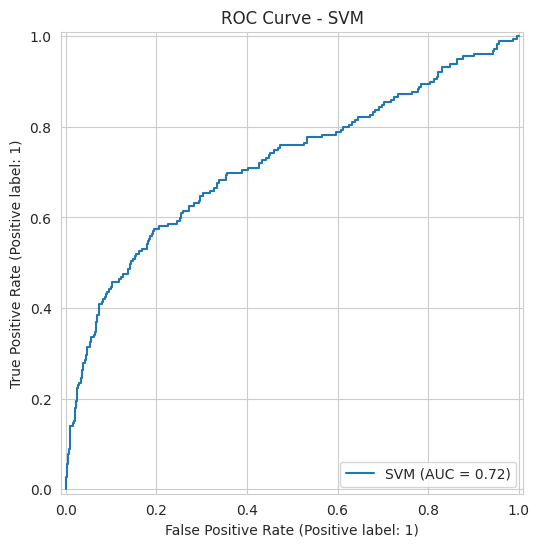


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression     0.839   0.680000  0.189944  0.296943  0.802768
7          Gaussian NB     0.795   0.439252  0.525140  0.478372  0.791609
2        Random Forest     0.838   0.742857  0.145251  0.242991  0.791510
5             AdaBoost     0.830   0.604651  0.145251  0.234234  0.787009
3    Gradient Boosting     0.840   0.686275  0.195531  0.304348  0.784797
4          Extra Trees     0.830   0.695652  0.089385  0.158416  0.782630
8                  SVM     0.830   0.714286  0.083799  0.150000  0.718690
6                  KNN     0.806   0.388060  0.145251  0.211382  0.659449
1        Decision Tree     0.754   0.306358  0.296089  0.301136  0.574963

BEST MODEL

Model        Logistic Regression
Accuracy                   0.839
Precision                   0.68
Recall                  0.189944
F1 Score                0.296943
ROC AUC                 0.802768
Name: 0, dtype: object


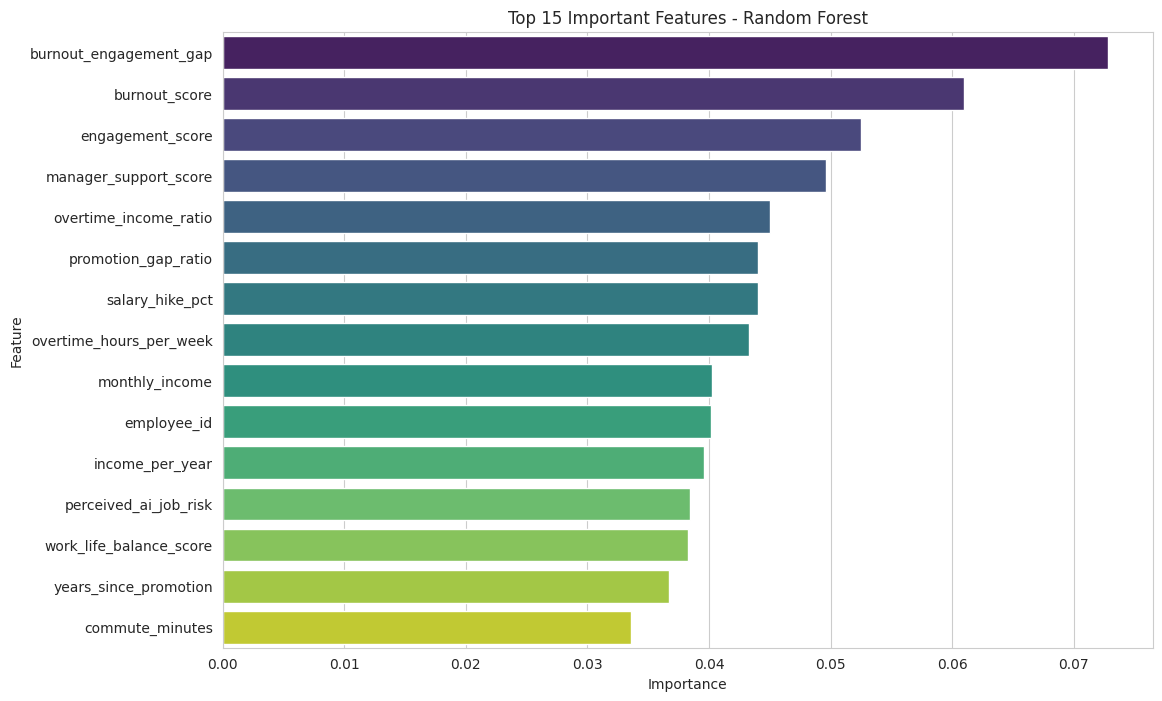


Top Important Features:

                    Feature  Importance
30   burnout_engagement_gap    0.072854
21            burnout_score    0.061005
22         engagement_score    0.052495
20    manager_support_score    0.049643
31    overtime_income_ratio    0.045040
29      promotion_gap_ratio    0.044072
10          salary_hike_pct    0.044051
17  overtime_hours_per_week    0.043310
8            monthly_income    0.040260
0               employee_id    0.040171
28          income_per_year    0.039598
27    perceived_ai_job_risk    0.038449
23  work_life_balance_score    0.038251
13    years_since_promotion    0.036748
16          commute_minutes    0.033614


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# COPY DATA
# =========================================================

data = df.copy()

# =========================================================
# FEATURE ENGINEERING
# =========================================================

data["income_per_year"] = (
    data["monthly_income"] * 12
) / (data["total_working_years"] + 1)

data["promotion_gap_ratio"] = (
    data["years_since_promotion"]
) / (data["years_at_company"] + 1)

data["burnout_engagement_gap"] = (
    data["burnout_score"]
    - data["engagement_score"]
)

data["overtime_income_ratio"] = (
    data["overtime_hours_per_week"]
) / (data["monthly_income"] + 1)

# =========================================================
# TARGET
# =========================================================

target = "attrition"

X = data.drop(columns=[target])
y = data[target]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# =========================================================
# LABEL ENCODING
# =========================================================

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    mapping = {
        cls: idx
        for idx, cls in enumerate(le.classes_)
    }

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = le

# Encode Target

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train.astype(str))

y_test = target_encoder.transform(y_test.astype(str))

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# MODELS
# =========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42)
}

# =========================================================
# TRAINING & EVALUATION
# =========================================================

results = []

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Models requiring scaling
    if name in ["Logistic Regression", "KNN", "SVM", "Gaussian NB"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(roc, 4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)
    plt.title(f"ROC Curve - {name}")
    plt.grid(True)
    plt.show()

    results.append([name, accuracy, precision, recall, f1, roc])

# =========================================================
# FINAL RESULT TABLE
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(by="ROC AUC", ascending=False)

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")
print(results_df)

# =========================================================
# BEST MODEL
# =========================================================

best = results_df.iloc[0]

print("\nBEST MODEL\n")
print(best)

# =========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================================================

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 15 Important Features - Random Forest")
plt.show()

print("\nTop Important Features:\n")
print(importance.head(15))

## Thanks........Please Upvote